#Bank Marketing Dataset Analysis and Prediction Model



**Introduction:** This project analyses the Bank Marketing dataset to understand customer behaviour and campaign outcomes. This involves Exploratory Data Analysis (EDA) to identify patterns and relationships within the data, followed by clustering to segment customers into meaningful groups. Additionally, both regression and classification models are developed to predict call duration and customer subscription to a term deposit. Model performance is evaluated using appropriate metrics to determine the most effective predictive approach and generate data-driven insights.

##Section 0

###Load Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To ignore non-critical warnings
import warnings
warnings.simplefilter('ignore')

# Set visual style for plots
sns.set(style='whitegrid')
%matplotlib inline

###Load Bank Dataset

In [ ]:
# Load the bank dataset
df = pd.read_csv('/content/bank-full-updated.csv')

## Section 1: EDA and pre-processing

###Exploratory data Analysis

In [ ]:
# Inspect dimensionality (rows, columns)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (45211, 18)


In [ ]:
# Show the first 10 rows to understand the data
display(df.head(10))

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0
5,5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,0
6,6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,0
7,7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,0
8,8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,0
9,9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,0


In [ ]:
# Summary of column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         45211 non-null  int64 
 1   age        45211 non-null  int64 
 2   job        45211 non-null  object
 3   marital    45211 non-null  object
 4   education  45211 non-null  object
 5   default    45211 non-null  object
 6   balance    45211 non-null  int64 
 7   housing    45211 non-null  object
 8   loan       45211 non-null  object
 9   contact    45211 non-null  object
 10  day        45211 non-null  int64 
 11  month      45211 non-null  object
 12  duration   45211 non-null  int64 
 13  campaign   45211 non-null  int64 
 14  pdays      45211 non-null  int64 
 15  previous   45211 non-null  int64 
 16  poutcome   45211 non-null  object
 17  y          45211 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 6.2+ MB


In [ ]:
# Summary of numerical columns
display(df.describe())

,ID,age,balance,day,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22605.000000,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,13051.435847,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,0.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,11302.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,22605.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,33907.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,45210.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


In [ ]:
#Check for missing values

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ID           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


*There is no missing value shown. But in the dataset has many unknown data.*


####Categorical Column analysis

In [ ]:
# Identify categorical columns (excluding the target 'y')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'y' in cat_cols:
    cat_cols.remove('y')

print(f"Categorical columns identified: {cat_cols}")

Categorical columns identified: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


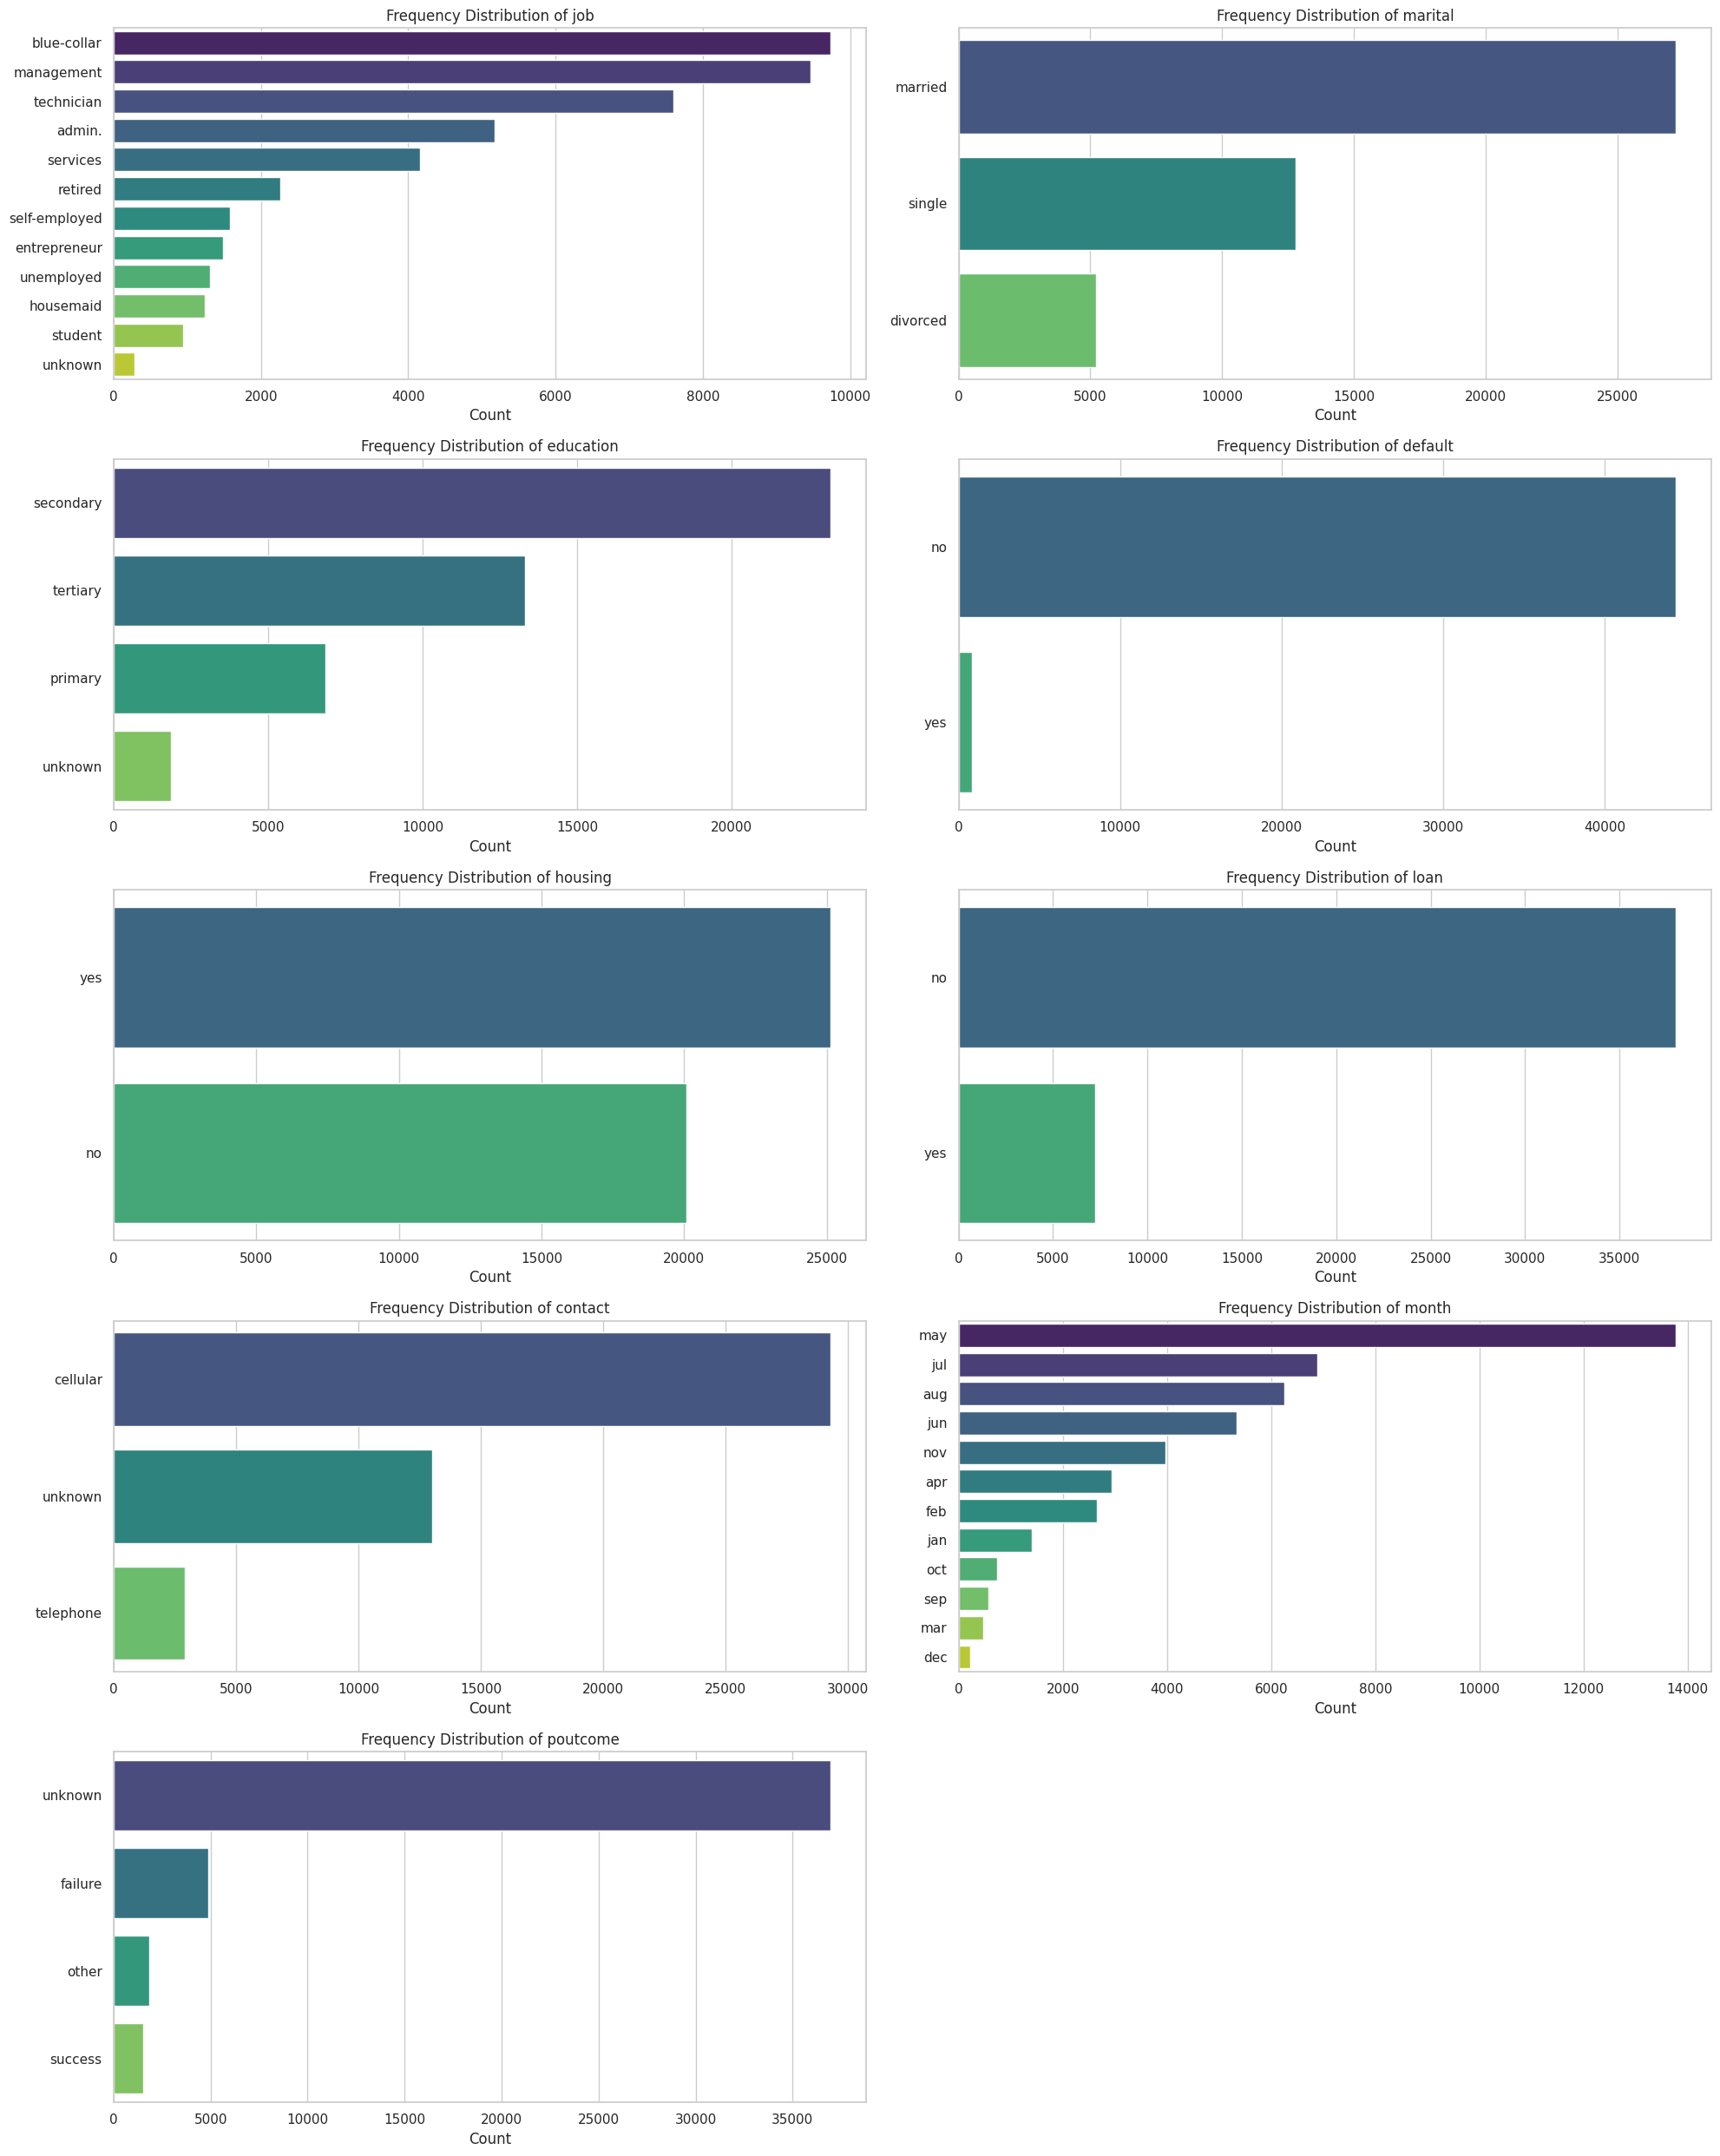

In [ ]:
# Plot frequency distributions for all categorical columns
plt.figure(figsize=(20, 25))

for i, col in enumerate(cat_cols):
    plt.subplot(5, 2, i+1)
    # Using value_counts to order the bars by frequency
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Frequency Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the frequency of 'unknown' values
unknown_stats = []

for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    percentage = (count / len(df)) * 100
    unknown_stats.append({
        'Feature': col,
        'Unknown Count': count,
        'Percentage (%)': round(percentage, 2)
    })

# Convert to DataFrame and sort
unknown_report = pd.DataFrame(unknown_stats).sort_values(by='Percentage (%)', ascending=False)

print("--- 'Unknown' Value Diagnostic Report ---")
display(unknown_report)

--- 'Unknown' Value Diagnostic Report ---


,Feature,Unknown Count,Percentage (%)
8,poutcome,36959,81.75
6,contact,13020,28.80
2,education,1857,4.11
0,job,288,0.64
1,marital,0,0.00
4,housing,0,0.00
3,default,0,0.00
5,loan,0,0.00
7,month,0,0.00


**Categorical Data Analysis:** Here we analyse categorical variables, such as job types, marital status, and education. After generating frequency distribution plots, we identified class imbalances and the prevalence of **"unknown"** values.

This is crucial for determining imputation strategies; for instance, features with a high percentage of **"unknown"** entries may require a dedicated label to prevent the loss of significant data patterns.

####Numerical Column analysis

In [ ]:
# Identify numerical columns (excluding ID and the target 'y')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in ['ID', 'y']:
    if col in num_cols:
        num_cols.remove(col)

print(f"Numerical columns identified for outlier analysis: {num_cols}")

Numerical columns identified for outlier analysis: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


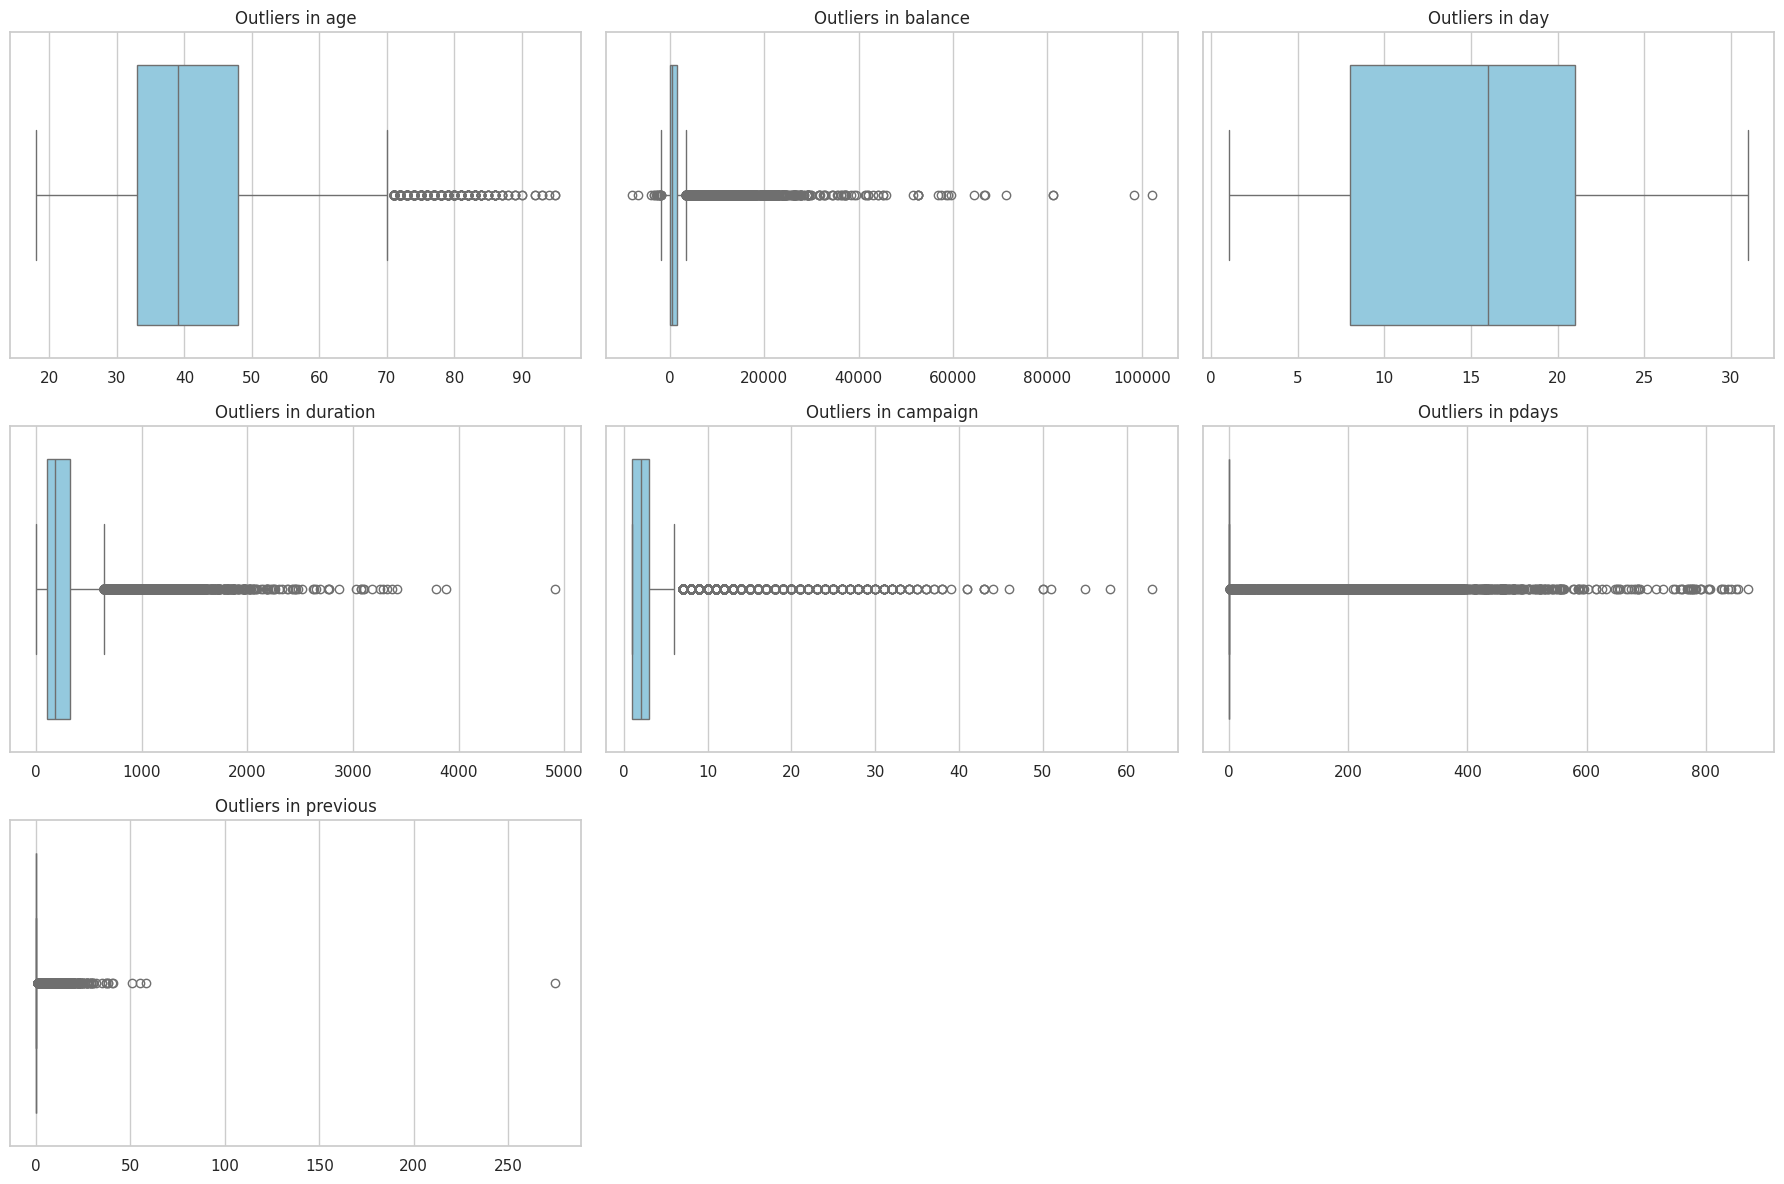

In [ ]:
# Visualise all numerical columns using boxplots

plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate and sort outliers using the Interquartile Range (IQR) method
outlier_data = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count rows outside the bounds
    count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    percentage = (count / len(df)) * 100

    outlier_data.append({
        'Feature': col,
        'Outlier Count': count,
        'Percentage (%)': round(percentage, 2)
    })

# Convert to DataFrame and sort by the highest percentage
outlier_report = pd.DataFrame(outlier_data).sort_values(by='Percentage (%)', ascending=False)

print("----------- Ordered Outlier Report --------------")
display(outlier_report)

----------- Ordered Outlier Report --------------


,Feature,Outlier Count,Percentage (%)
6,previous,8257,18.26
5,pdays,8257,18.26
1,balance,4729,10.46
3,duration,3235,7.16
4,campaign,3064,6.78
0,age,487,1.08
2,day,0,0.00


**Neumerical Data Analysis:** Numerical features like age, balance, and duration are scrutinized using boxplots to detect outliers. As we can see, data are right skewd and has many outliers.  



## Section 1.1: Common code for pre-processing
*Note: Try to avoid repeating yourself. Include any code common to both of your pre-processing approaches here.*

In [ ]:
# Capping 3 features with the most significant outlier issues
cols_to_cap = ['balance', 'duration', 'campaign']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping using the clip function
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print(f"Outliers capped for: {cols_to_cap}")

Outliers capped for: ['balance', 'duration', 'campaign']


In [ ]:
# Display unique values to determine order
for col in cat_cols:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in marital: ['married' 'single' 'divorced']
Unique values in education: ['tertiary' 'secondary' 'unknown' 'primary']
Unique values in default: ['no' 'yes']
Unique values in housing: ['yes' 'no']
Unique values in loan: ['no' 'yes']
Unique values in contact: ['unknown' 'cellular' 'telephone']
Unique values in month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Unique values in poutcome: ['unknown' 'failure' 'other' 'success']


**Ordinal:** Among all the features education a natural progression (Primary < Secondary < Tertiary). So this is ordinal feature.

**Nominal:** Other features like in job or marital there is no mathematical order. So, they are nominal features. These must be one-hot encoded.


In [ ]:
# Defining strategy thresholds
impute_threshold = 5.0  # Percentage below which we replace 'unknown' with the Mode
rare_threshold = 1.0    # Percentage below which we replace a label to reduce noise

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'y' in cat_cols: cat_cols.remove('y')

for col in cat_cols:
    # Handle 'unknown' values based on the 5% threshold
    unknown_count = (df[col] == 'unknown').sum()
    unknown_pct = (unknown_count / len(df)) * 100

    if 0 < unknown_pct < impute_threshold:
        # Find the mode excluding the 'unknown' label itself
        mode_val = df[df[col] != 'unknown'][col].mode()[0]
        df[col] = df[col].replace('unknown', mode_val)
        print(f"Imputed 'unknown' in {col}: {unknown_pct:.2f}% replaced with '{mode_val}'")
    elif unknown_pct >= impute_threshold:
        print(f"Kept 'unknown' in {col}: {unknown_pct:.2f}% is above threshold")

    #  Handle Rare Categories (labels < 1%)
    # We re-calculate counts after imputation to be accurate
    counts = df[col].value_counts(normalize=True) * 100
    # Identify labels that are not 'unknown' but are very rare
    rare_labels = counts[(counts < rare_threshold) & (counts.index != 'unknown')].index.tolist()

    if rare_labels:
        mode_val = df[col].mode()[0]
        df[col] = df[col].replace(rare_labels, mode_val)
        print(f"   --> Replaced rare labels in {col}: {rare_labels} with '{mode_val}'")

print("\nCategorical data cleaning complete.")

Imputed 'unknown' in job: 0.64% replaced with 'blue-collar'
Imputed 'unknown' in education: 4.11% replaced with 'secondary'
Kept 'unknown' in contact: 28.80% is above threshold
   --> Replaced rare labels in month: ['dec'] with 'may'
Kept 'unknown' in poutcome: 81.75% is above threshold

Categorical data cleaning complete.


A dual-threshold approach was implemented for categorical data cleaning.

For columns where 'unknown' values represented less than 5% of the observations (such as Job and Education), Mode Imputation was used to maintain dataset integrity.

However, for columns like 'poutcome' where 'unknown' frequency exceeded 5%, the label was retained as a distinct category to preserve potentially significant predictive signals.

Finally, any category appearing in less than 1% of the dataset was aggregated into the mode to prevent model overfitting on statistically insignificant noise.

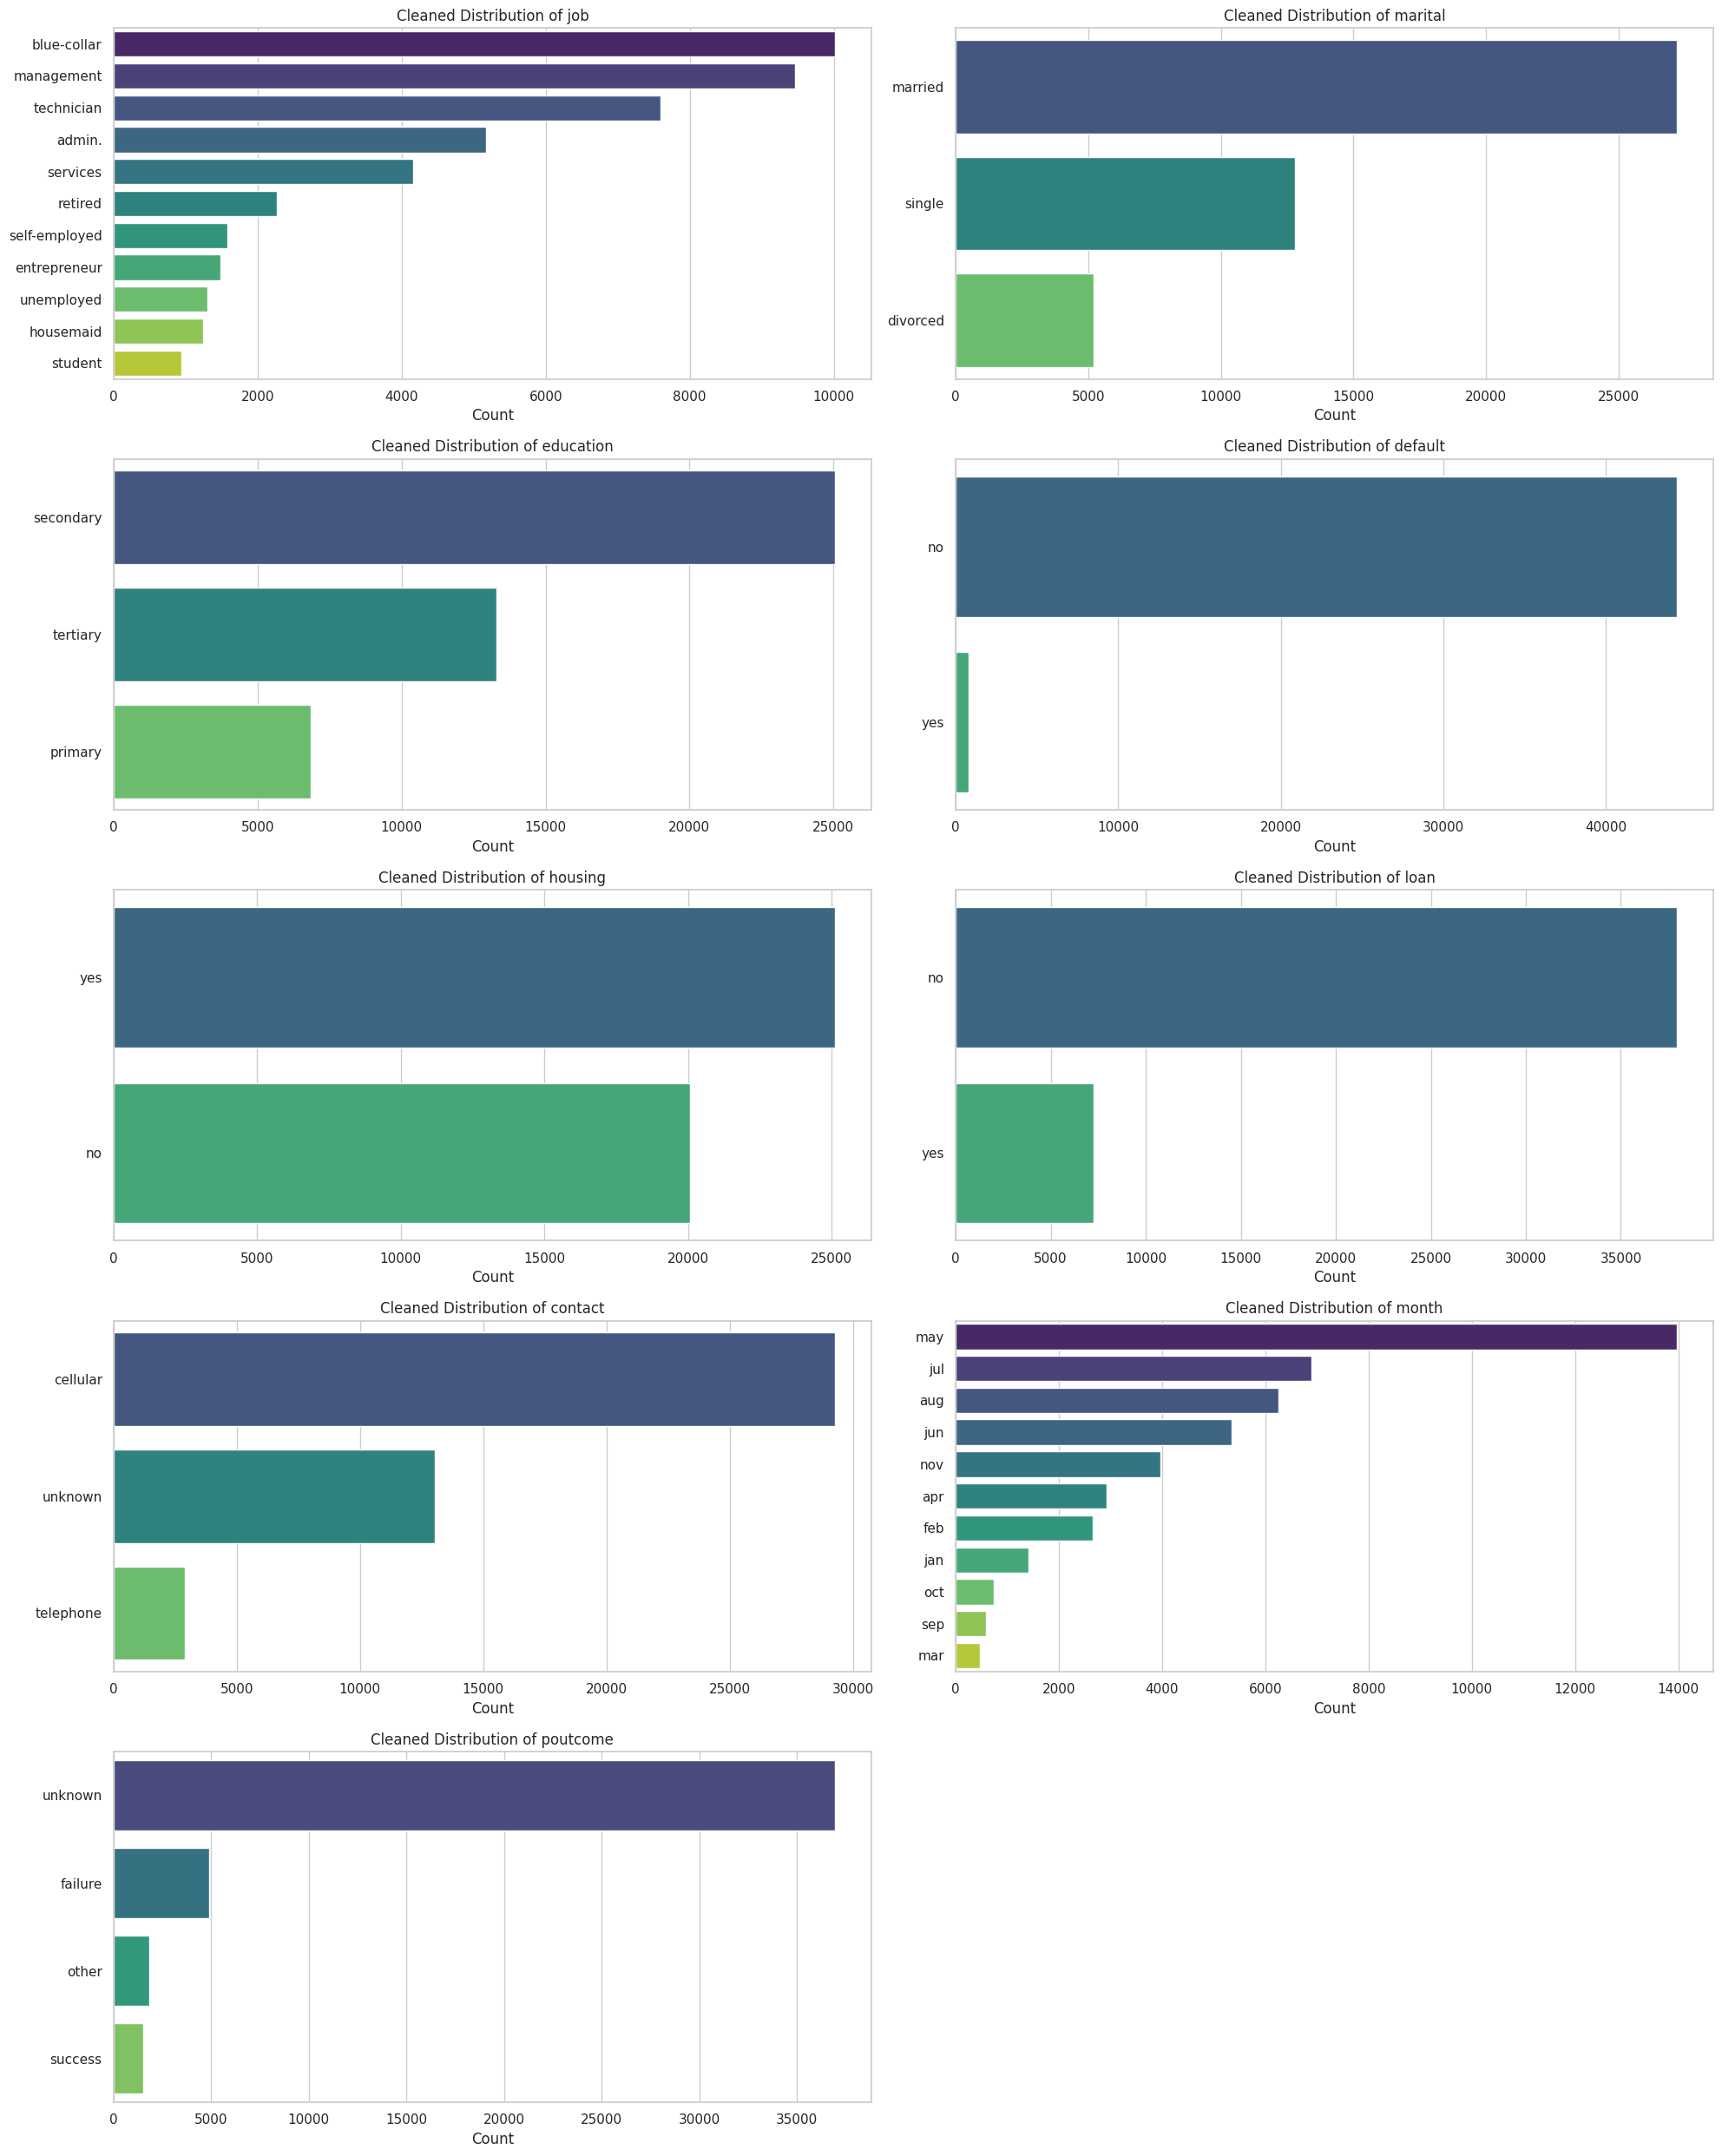

--- Unique Values After Cleaning ---
job: ['management', 'technician', 'entrepreneur', 'blue-collar', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']
marital: ['married', 'single', 'divorced']
education: ['tertiary', 'secondary', 'primary']
default: ['no', 'yes']
housing: ['yes', 'no']
loan: ['no', 'yes']
contact: ['unknown', 'cellular', 'telephone']
month: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'jan', 'feb', 'mar', 'apr', 'sep']
poutcome: ['unknown', 'failure', 'other', 'success']


In [ ]:
# Identify categorical columns again (excluding target 'y')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'y' in cat_cols: cat_cols.remove('y')

# Plot frequency distributions after cleaning
plt.figure(figsize=(20, 25))

for i, col in enumerate(cat_cols):
    plt.subplot(5, 2, i+1)
    # Order by count to see the distribution clearly
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Cleaned Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Print a summary of unique values after cleaning to confirm
print("--- Unique Values After Cleaning ---")
for col in cat_cols:
    print(f"{col}: {df[col].unique().tolist()}")

After Imputation and removing statistically insignificant labels, we have reduced the risk of the model learning from 'noise,' ensuring that the final classification and clustering models focus on patterns with strong evidential support.

In [ ]:
# --- Ordinal Encoding for 'education' ---

# primary -> 0, secondary -> 1, tertiary -> 2

education_order = ['primary', 'secondary', 'tertiary']
df['education_encoded'] = pd.Categorical(df['education'], categories=education_order, ordered=True).codes

# Nominal Encoding (One-Hot) for other categories ---

#new binary columns (0 or 1) for each category.
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# We set dtype=int to ensure the output is numerical for the ML models
df_encoded = pd.get_dummies(df, columns=nominal_cols, prefix=nominal_cols, dtype=int)

# Target Variable Encoding ---
# The 'y' column is already 0/1 after initial loading, so no re-mapping needed.
# We just need to make sure the df_encoded 'y' column is correctly set.
# The original 'y' in `df` is already int64 (0 or 1), as seen in df.info().
# When df_encoded is created from df, it copies this 'y' column.
# So, this line is not needed and would introduce NaNs if 'y' was already 0/1.
# df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# Let's ensure df_encoded's 'y' column is directly from the original df and is int.
df_encoded['y'] = df['y'].astype(int)

# Drop the original 'education' text column and 'ID'
df_encoded = df_encoded.drop(columns=['education', 'ID'], errors='ignore')

print("Encoding complete. The dataset is now fully numerical.")
print(f"Total features after encoding: {df_encoded.shape[1]}")
df_encoded.head(10)

Encoding complete. The dataset is now fully numerical.
Total features after encoding: 47


,age,balance,day,duration,campaign,pdays,previous,y,education_encoded,job_admin.,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,2,0,...,0,0,1,0,0,0,0,0,0,1
1,44,29,5,151,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,33,2,5,76,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
3,47,1506,5,92,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
4,33,1,5,198,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
5,35,231,5,139,1,-1,0,0,2,0,...,0,0,1,0,0,0,0,0,0,1
6,28,447,5,217,1,-1,0,0,2,0,...,0,0,1,0,0,0,0,0,0,1
7,42,2,5,380,1,-1,0,0,2,0,...,0,0,1,0,0,0,0,0,0,1
8,58,121,5,50,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
9,43,593,5,55,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1


All the categorical values are now encoded.

In [ ]:
# Calculate variance for all columns in the encoded dataframe
# We look for features where variance is near zero

variances = df_encoded.var().sort_values()

print("--- Bottom 5 Features by Variance ---")
print(variances.head(5))

# Identify columns with variance lower than 0.01
low_var_cols = variances[variances < 0.01].index.tolist()

if not low_var_cols:
    print("\nResult: No features found below the 0.01 threshold. All features retained.")
else:
    df_encoded = df_encoded.drop(columns=low_var_cols)
    print(f"\nDropped columns: {low_var_cols}")

--- Bottom 5 Features by Variance ---
month_mar      0.010439
month_sep      0.012643
month_oct      0.016057
default_yes    0.017702
default_no     0.017702
dtype: float64

Result: No features found below the 0.01 threshold. All features retained.


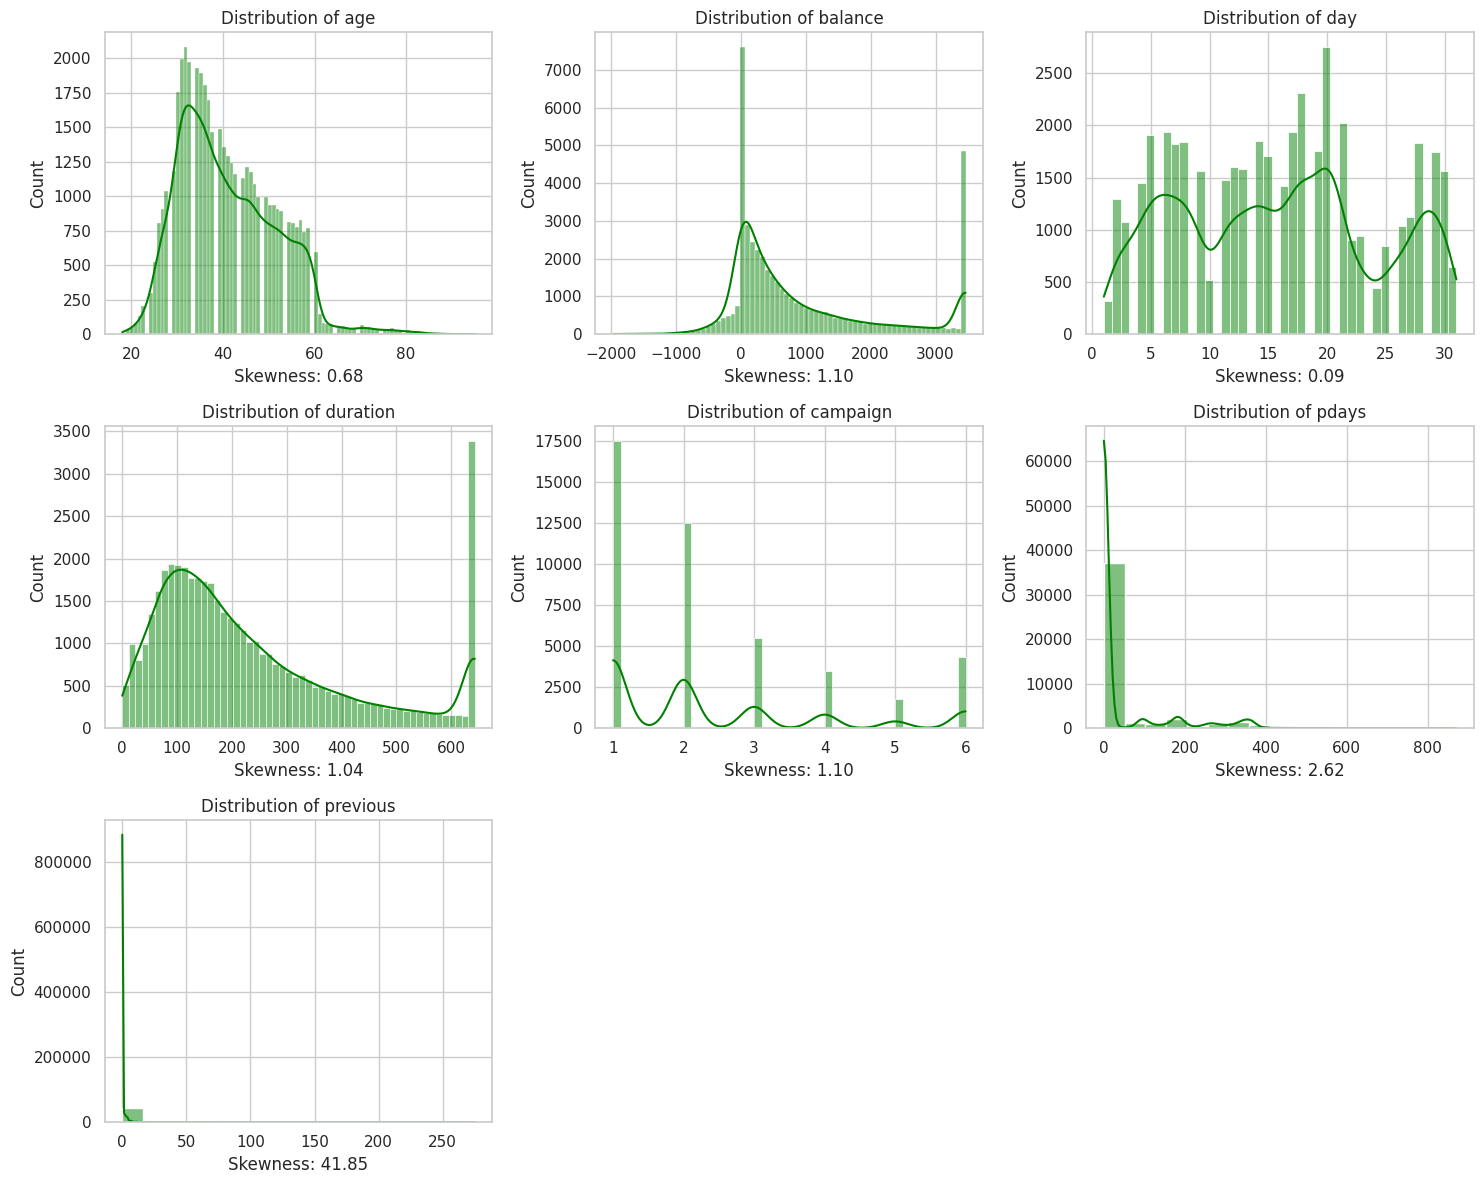

In [ ]:
# Select the numerical columns we analyzed before
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Plot Histograms to see the 'tails'
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='green')
    plt.title(f'Distribution of {col}')

    # Calculate Skewness
    skew_val = df[col].skew()
    plt.xlabel(f'Skewness: {skew_val:.2f}')

plt.tight_layout()
plt.show()

In the dataset, Data are not normally distributed(Gausian).The presence of right tails indicates extreme values, causing the mean to be greater than the median, a small number of extreme observations significantly influence the distribution.

## Section 1.2: FIRST PRE-PROCESSING APPROACH (STANDARD SCALER)


Standard Scaler standardizes features by removing the mean and scaling them to unit variance. It is appropriate for our dataset because the features are measured on different scales and contain outliers. This method centers the data around zero while preserving the influence of extreme values, making it suitable for models that are sensitive to feature magnitude.

In [ ]:
# Identify columns to scale
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Method 1: Standard Scaler (Standardization)
ss = StandardScaler()
df_standard = df_encoded.copy()
df_standard[num_cols] = ss.fit_transform(df_encoded[num_cols])

## Section 1.3: SECOND PRE-PROCESSING APPROACH (MIN-MAX SCALER)


Min-Max Scaler rescales features to a fixed range (typically 0 to 1). It was selected because the data do not follow a Gaussian (normal) distribution, and normalization helps bring features to a comparable scale without assuming normality.

In [ ]:
# Method 2: Min-Max Scaler (Normalization)
mm = MinMaxScaler()
df_minmax = df_encoded.copy()
df_minmax[num_cols] = mm.fit_transform(df_encoded[num_cols])

Although a Robust Scaler could also be applied due to the presence of outliers, Min-Max scaling was intentionally used to compare how model performance differs when extreme values are preserved versus when the data are compressed into a bounded range. This comparison helps evaluate the impact of scaling techniques on skewed distributions.

## Section 1.4: Selection of Final Approach


I choose standard scaler for our dataset after several calculations and visualisations.



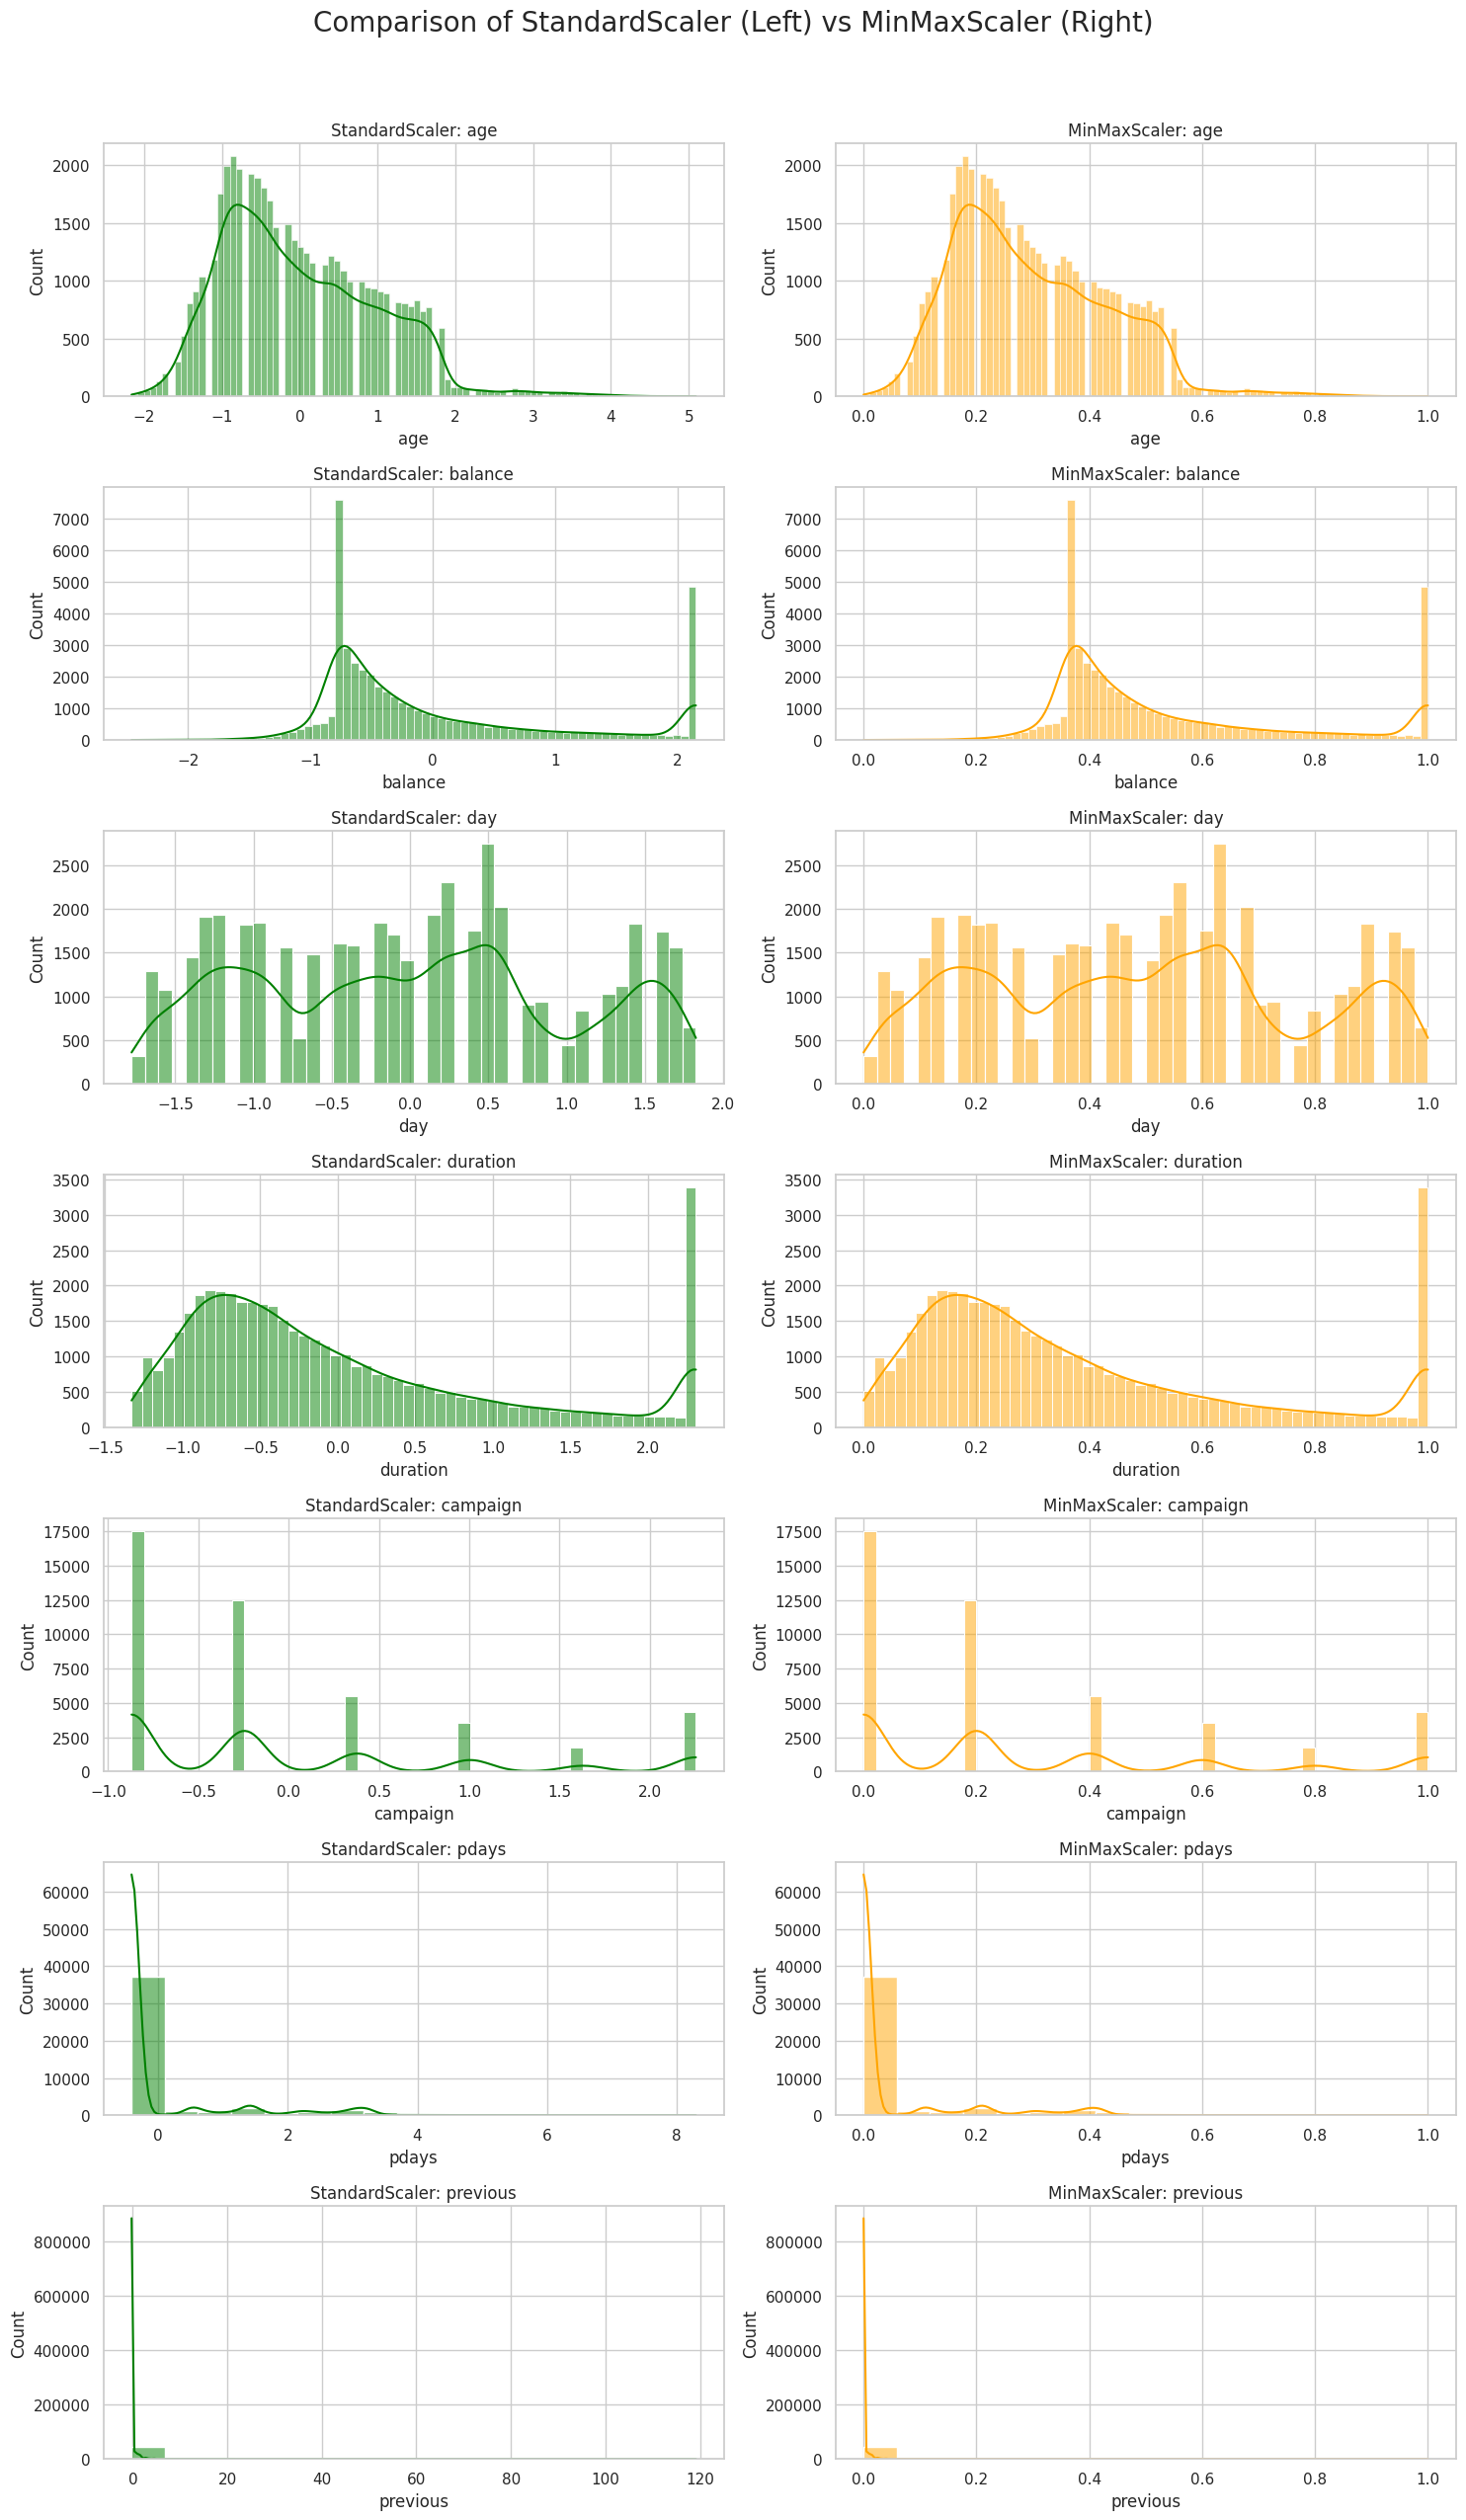

In [ ]:
#Visualize the comparison for ALL columns
fig, axes = plt.subplots(len(num_cols), 2, figsize=(15, 25))

for i, col in enumerate(num_cols):
    # Plot StandardScaler results
    sns.histplot(df_standard[col], kde=True, ax=axes[i, 0], color='green')
    axes[i, 0].set_title(f'StandardScaler: {col}')

    # Plot MinMaxScaler results
    sns.histplot(df_minmax[col], kde=True, ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'MinMaxScaler: {col}')

plt.suptitle('Comparison of StandardScaler (Left) vs MinMaxScaler (Right)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#Generate a statistical comparison of the 'Tails'
comparison_stats = []
for col in num_cols:
    comparison_stats.append({
        'Feature': col,
        'SS Range (Min to Max)': f"{df_standard[col].min():.2f} to {df_standard[col].max():.2f}",
        'MM Range (Min to Max)': f"{df_minmax[col].min():.2f} to {df_minmax[col].max():.2f}",
        'Skewness': round(df_encoded[col].skew(), 2)
    })

display(pd.DataFrame(comparison_stats))

,Feature,SS Range (Min to Max),MM Range (Min to Max),Skewness
0,age,-2.16 to 5.09,0.00 to 1.00,0.68
1,balance,-2.46 to 2.15,0.00 to 1.00,1.10
2,day,-1.78 to 1.83,0.00 to 1.00,0.09
3,duration,-1.33 to 2.31,0.00 to 1.00,1.04
4,campaign,-0.87 to 2.25,0.00 to 1.00,1.10
5,pdays,-0.41 to 8.30,0.00 to 1.00,2.62
6,previous,-0.25 to 119.14,0.00 to 1.00,41.85


In [ ]:
# Final Decision: Proceed with StandardScaler as it preserves variance in skewed data
df_final = df_standard.copy()

print("Decision finalized: Proceeding with StandardScaler for all subsequent modeling.")

Decision finalized: Proceeding with StandardScaler for all subsequent modeling.


After visualizing the distributions, I observed that almost all numerical features—specifically balance, duration, and campaign—possess significant right-side skewness (long tails).

**Why not using MinMaxScaler:** In the comparison plots, MinMaxScaler (Orange) 'squashed' the bulk of the data into a tiny interval near zero. Because the scale is fixed between 0 and 1, the long tails act as anchors, reducing the variance and detail in the majority of the observations.

**Why using StandardScaler:** StandardScaler (Green) centered the data at the mean (0) and scaled it based on standard deviations. This preserved the variance and the relative distance between points much more effectively.

**Final Decision:** I have selected StandardScaler. For the next phase of this project, preserving the variance is crucial to ensure the algorithm can accurately calculate Euclidean distances and distinguish between different customer segments in our case.

##Section 1.5: Correlation

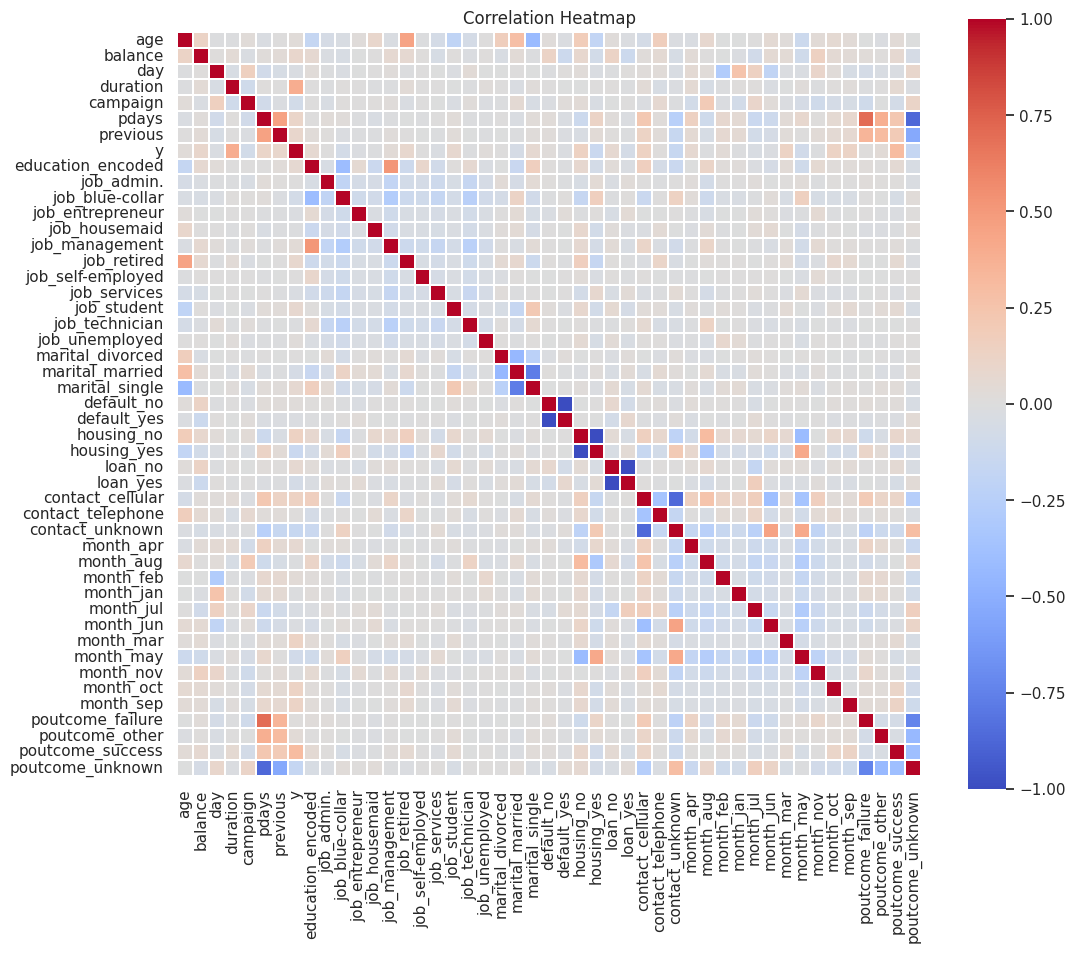

Features exceeding the 0.8 threshold: ['default_yes', 'housing_yes', 'loan_yes', 'contact_unknown', 'poutcome_unknown']


In [ ]:
# Compute the Correlation Matrix for the entire encoded/scaled dataset
corr_matrix = df_final.corr()

# Identify features with correlation > 0.8 (ignoring the 1.0 diagonal)
# This helps to justify 'Drop' decisions in the report
high_corr = corr_matrix.abs()
upper = high_corr.where(np.triu(np.ones(high_corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]



# Plotting with a bit more detail
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, square=True, linewidths=.1)
plt.title('Correlation Heatmap')
plt.show()

print(f"Features exceeding the 0.8 threshold: {to_drop}")

Successfully dropped: ['default_yes', 'housing_yes', 'loan_yes', 'contact_unknown', 'poutcome_unknown']


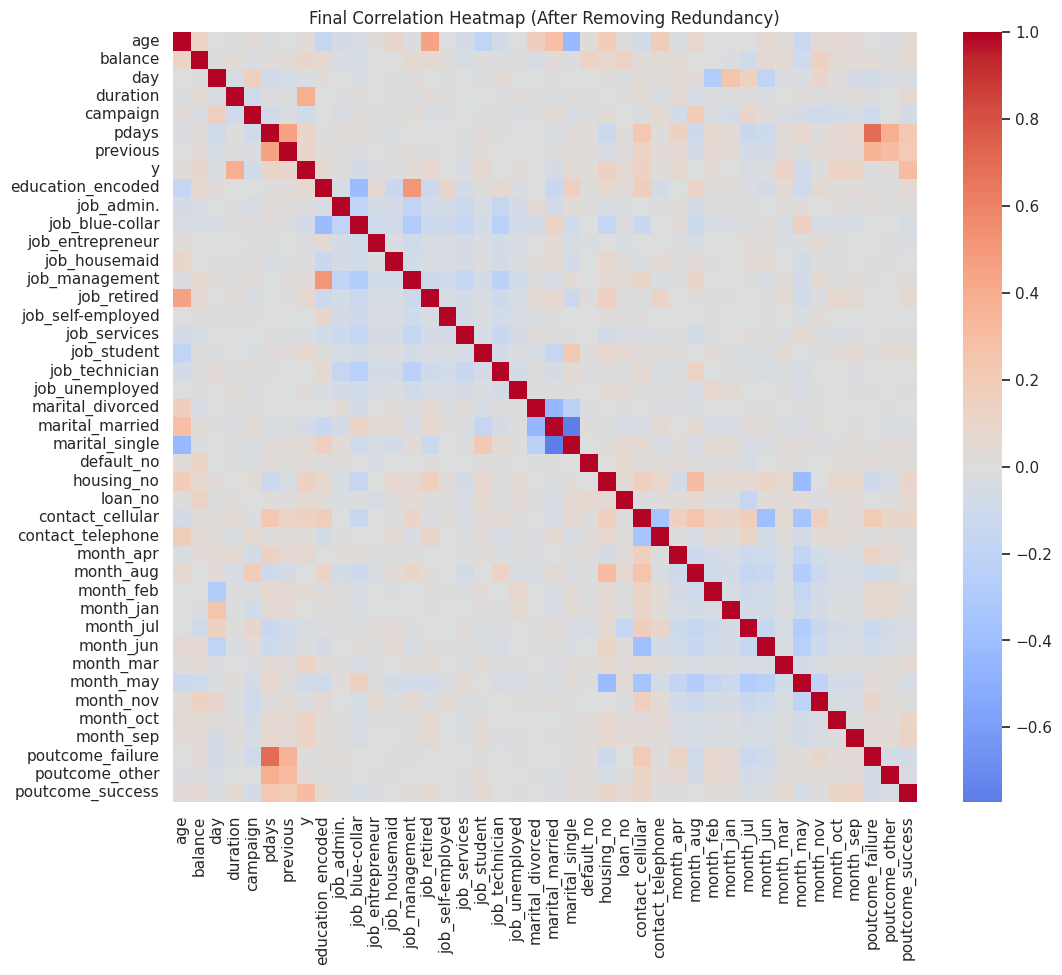

Final dataset dimensions: (45211, 42)


In [ ]:
# Execute the drop based on the 'to_drop' list we calculated
if to_drop:
    # errors='ignore' prevents the code from crashing if you run the cell twice
    df_final = df_final.drop(columns=to_drop, errors='ignore')
    print(f"Successfully dropped: {to_drop}")
else:
    print("No columns were identified for dropping.")

# Re-calculate the correlation matrix for the CLEANED data
final_corr = df_final.corr()

# Generate the 'After' Heatmap using the NEW final_corr matrix
plt.figure(figsize=(12,10))

# We use final_corr here, and removed the 'mask' parameter to show the full square
sns.heatmap(final_corr,
            cmap='coolwarm',
            center=0,
            annot=False)

plt.title('Final Correlation Heatmap (After Removing Redundancy)')
plt.show()

print(f"Final dataset dimensions: {df_final.shape}")

Now, the models will not be confused by redundant predictors, leading to more stable coefficients and distinct clusters.

##Principle Component Analysis

Following the encoding and scaling of the 45,211 records, the feature space expanded significantly. To mitigate the **'Curse of Dimensionality'** and improve the performance of distance-based algorithms like K-Means and DBSCAN, I applied **Principal Component Analysis (PCA)**

Features used for Clustering: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'education_encoded', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'default_no', 'housing_no', 'loan_no', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success']


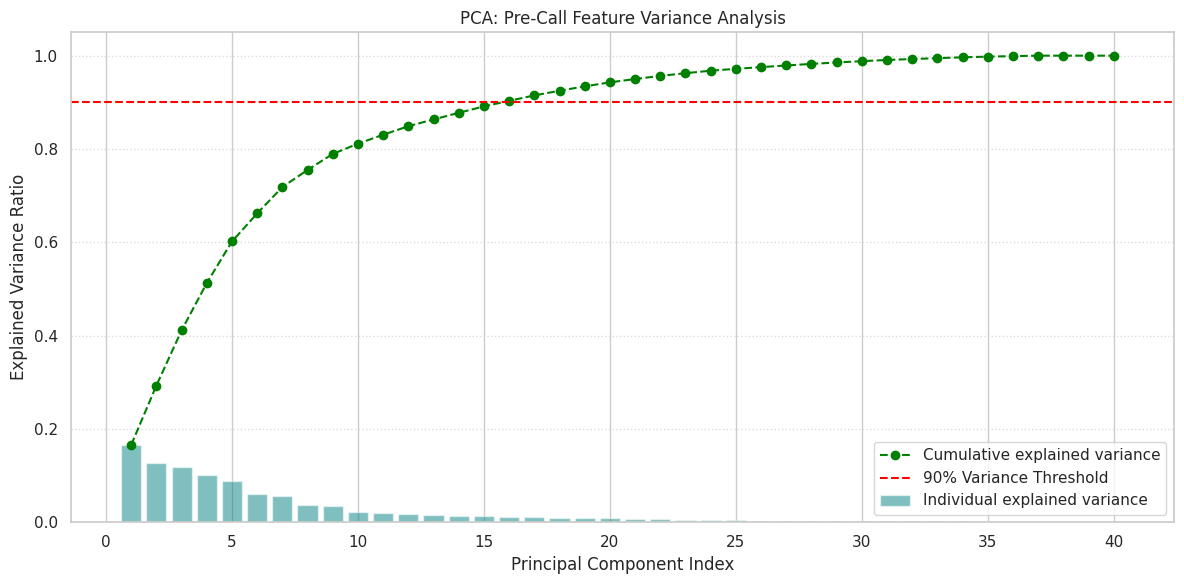

PCA complete. Retained 16 components.


In [ ]:

# Define the features to exclude based on the brief
# 'duration' is post-call info, and 'y' is the outcome
excluded_cols = ['duration', 'y']

# Filter the dataframe to include ONLY pre-call features
X_pre_call = df_final.drop(columns=[col for col in excluded_cols if col in df_final.columns])

print(f"Features used for Clustering: {X_pre_call.columns.tolist()}")

# Initial PCA to calculate variance
pca_full = PCA()
pca_full.fit(X_pre_call)

# Calculate Explained Variance and Cumulative Variance
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Visualize the Explained Variance
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center',
        label='Individual explained variance', color='teal')
plt.plot(range(1, len(cum_var) + 1), cum_var, marker = 'o', linestyle='--',
         label='Cumulative explained variance', color='green')


plt.axhline(y=0.90, color='red', linestyle='--', label='90% Variance Threshold')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('PCA: Pre-Call Feature Variance Analysis')
plt.legend(loc='best')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Transform the data into the final Principal Components
n_components_90 = np.argmax(cum_var >= 0.90) + 1
pca_final = PCA(n_components=n_components_90)
df_pca = pd.DataFrame(pca_final.fit_transform(X_pre_call),
                      columns=[f'PC{i+1}' for i in range(n_components_90)])

print(f"PCA complete. Retained {n_components_90} components.")

we reduced the complexity of our data by 60% while keeping 90% of the information.

**Key Limitations-**

**EDA:**

* Insights are static, may not reflect changing customer behavior.
* Correlation does not imply causation.
* Outlier handling can remove high-value customers.

**Pre-processing:**

* PCA discards some variance (information loss).
* “Unknown” labels may add noise.
* StandardScaler affected by skewed features.

* Those limitations can reduce model accuracy and interpretability.


*****
## Section 2: Clustering

## Section 2.1: Common code for clustering


###The Elbow Method

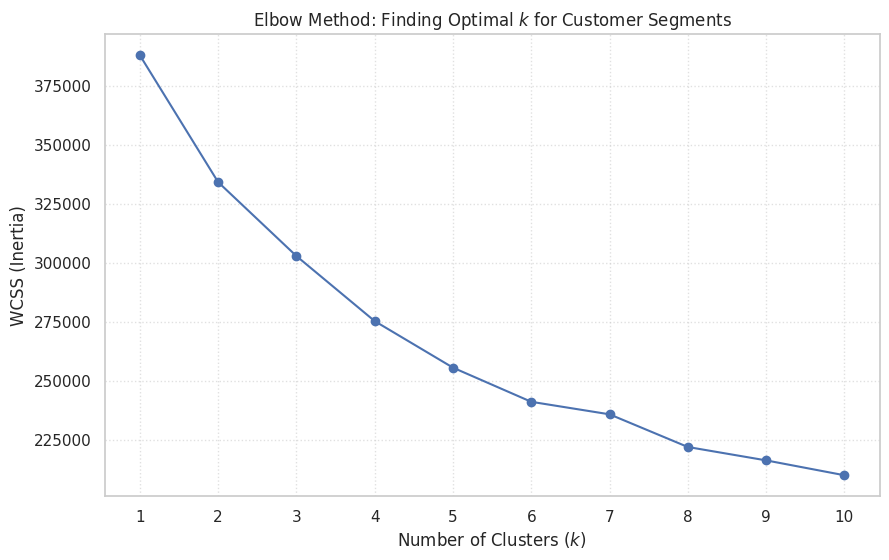

In [ ]:
# Calculate WCSS for a range of clusters (1 to 10)
wcss = []
k_range = range(1, 11)

for k in k_range:
    # random_state=42 ensures our results are the same every time we run it
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_pca) # We use the 16 PCA components
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')

plt.title('Elbow Method: Finding Optimal $k$ for Customer Segments')
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

From the graph above, the line stops dropping vertically and starts to flatten out from 2, also flatten out from 4 and 6.

###Silhouette Score

In [ ]:
# Test k=2, to 10
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    print(f"For k={k}, Silhouette Score is: {score:.4f}")

For k=2, Silhouette Score is: 0.2467
For k=3, Silhouette Score is: 0.1219
For k=4, Silhouette Score is: 0.1325
For k=5, Silhouette Score is: 0.1280
For k=6, Silhouette Score is: 0.1240
For k=7, Silhouette Score is: 0.1193
For k=8, Silhouette Score is: 0.1197
For k=9, Silhouette Score is: 0.1093
For k=10, Silhouette Score is: 0.1087


Here, k=2 has the highest and k=4 has the second highest Silhouette Score.

But for the clustering I choose k=4 as it can be the best balance for customer segmentation. k=2 will be too "broad." It won't give much detail.


## Section 2.2: FIRST CLUSTERING APPROACH (K-Means)


K-Means was selected as a centroid-based clustering algorithm due to its efficiency and suitability for numerical data. It is effective for identifying compact, well-separated clusters and allows evaluation of the optimal number of clusters. (we choose 4 based on evidence)

In [ ]:
# Assuming k=4 based on Elbow/Silhouette analysis
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
# We add the cluster labels back to our MAIN dataframe for future sections
df_final['Segment_Label'] = kmeans_final.fit_predict(df_pca)

print(f"Clusters assigned. Value counts:\n{df_final['Segment_Label'].value_counts()}")

Clusters assigned. Value counts:
Segment_Label
2    17128
0    13702
3     8248
1     6133
Name: count, dtype: int64


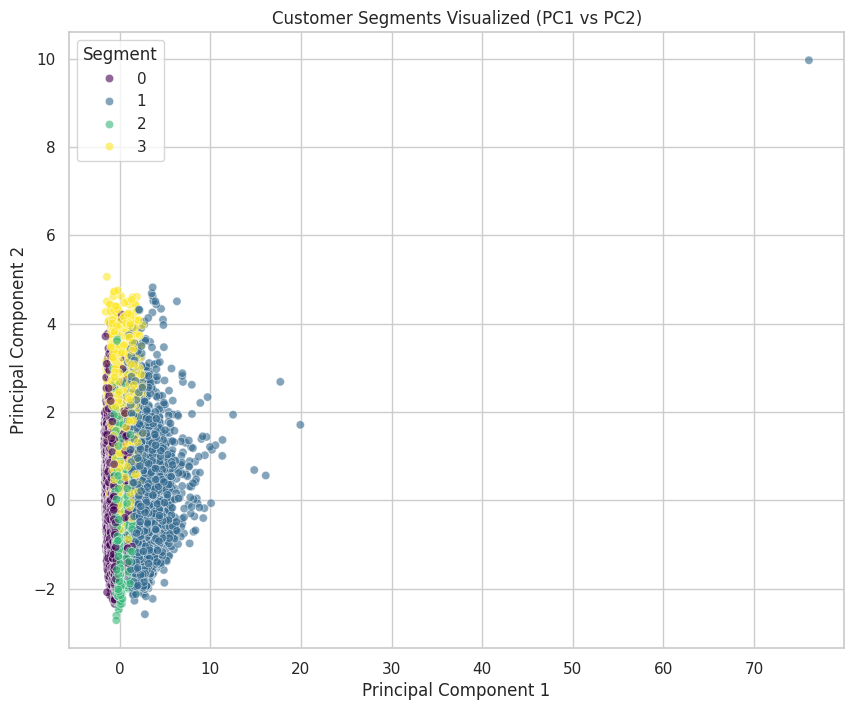

Customer distribution across segments:
Segment_Label
2    17128
0    13702
3     8248
1     6133
Name: count, dtype: int64


In [ ]:
# Run the final K-Means model with k=4
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(df_pca)

# Add the Segment Label back to our main dataframe
df_final['Segment_Label'] = cluster_labels

# Visualize the Clusters using the first two PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df_pca.iloc[:, 0], y=df_pca.iloc[:, 1],
                hue=df_final['Segment_Label'], palette='viridis', alpha=0.6)

plt.title('Customer Segments Visualized (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Segment')
plt.show()

# Check the size of each segment
print("Customer distribution across segments:")
print(df_final['Segment_Label'].value_counts())

In [ ]:
# Group by the new segment labels and look at the average of key features
segment_analysis = df_final.groupby('Segment_Label')[['age', 'balance', 'previous', 'education_encoded']].mean()
print("Segment Characteristics (Means):")
print(segment_analysis)

Segment Characteristics (Means):
                    age   balance  previous  education_encoded
Segment_Label                                                 
0             -0.026798 -0.456076 -0.226941           1.164429
1             -0.085541 -0.087841  1.295609           1.151639
2             -0.120133 -0.446453 -0.221778           1.092130
3              0.357596  1.750088 -0.125826           1.204777


## Section 2.3: SECOND CLUSTERING APPROACH (DBSCAN)


DBSCAN was chosen as a density-based clustering method capable of detecting arbitrarily shaped clusters and identifying noise or outliers. Unlike K-Means, it does not require pre-specifying the number of clusters.

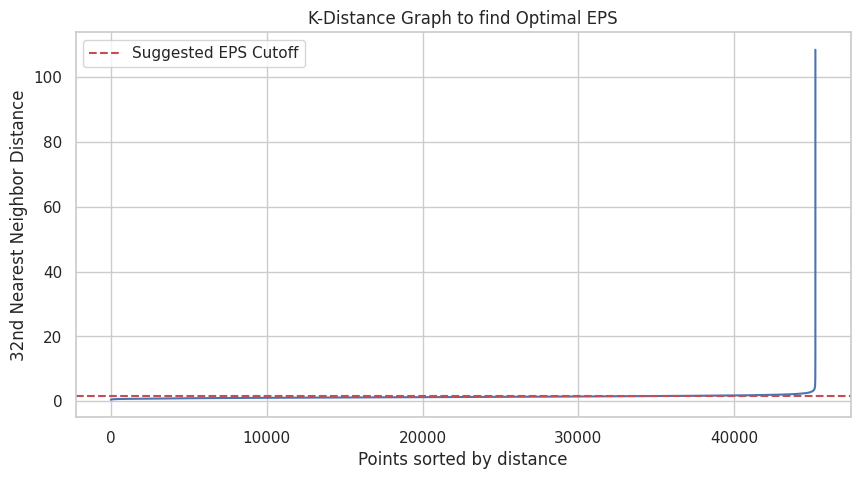

In [ ]:
from sklearn.neighbors import NearestNeighbors

# We use 2 * number of features as the standard for min_samples
# Since we have 16 PCA components, 32 is a solid choice.
neighbors = NearestNeighbors(n_neighbors=32)
neighbors_fit = neighbors.fit(df_pca)
distances, indices = neighbors_fit.kneighbors(df_pca)

# Sort distances to see the 'elbow' or 'knee'
distances = np.sort(distances[:, 31], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph to find Optimal EPS')
plt.xlabel('Points sorted by distance')
plt.ylabel('32nd Nearest Neighbor Distance')
plt.axhline(y=1.5, color='r', linestyle='--', label='Suggested EPS Cutoff') # Adjust y based on your curve
plt.legend()
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# ADJUST 'eps' based on where your graph above 'bends' upward
# If you are unsure, start with 1.5
dbscan = DBSCAN(eps=1.5, min_samples=32)
db_labels = dbscan.fit_predict(df_pca)

# Add to your main dataframe
df_final['DBSCAN_Label'] = db_labels

# See the results
print("DBSCAN Cluster Distribution:")
print(df_final['DBSCAN_Label'].value_counts())

DBSCAN Cluster Distribution:
DBSCAN_Label
 0    40589
-1     4609
 1       13
Name: count, dtype: int64


In [ ]:
n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_ = list(db_labels).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')
print(f'Percentage of noise: {(n_noise_ / len(df_final)) * 100:.2f}%')

Estimated number of clusters: 2
Estimated number of noise points: 4609
Percentage of noise: 10.19%


In [ ]:
# This shows how our K-Means segments (rows) match our DBSCAN groups (columns)
print(pd.crosstab(df_final['Segment_Label'], df_final['DBSCAN_Label']))

DBSCAN_Label     -1      0   1
Segment_Label                 
0               525  13177   0
1              2669   3464   0
2               224  16904   0
3              1191   7044  13


## Section 2.4: Selection of Final Approach


To decide which clusturing method to use, I do some mathmatical comparison below:

--- Clustering Evidential Comparison ---


,Metric,K-Means,DBSCAN
0,Silhouette Score (Density),0.1325,0.0670
1,Calinski-Harabasz (Separation),6168.7896,13.9758
2,Data Coverage (%),100.0000,89.8056


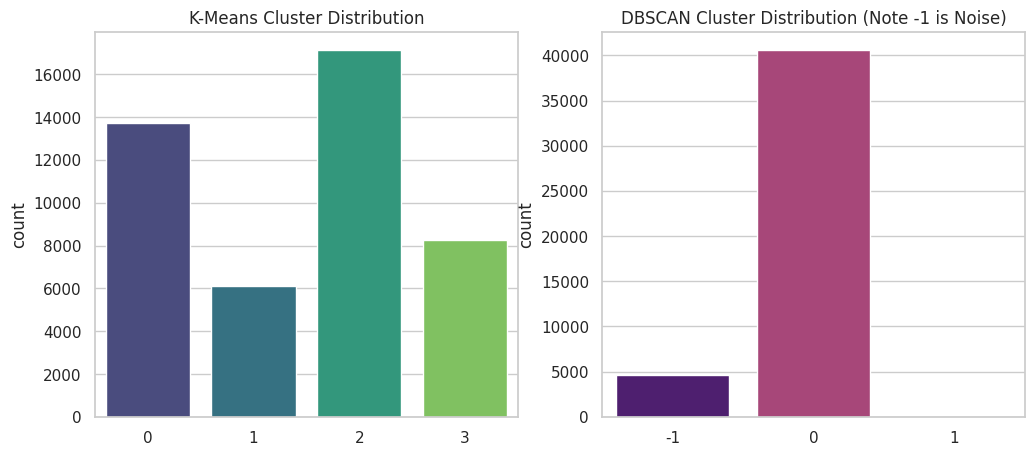

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Evaluate K-Means
kmeans_labels = kmeans_final.labels_
km_silhouette = silhouette_score(df_pca, kmeans_labels)
km_calinski = calinski_harabasz_score(df_pca, kmeans_labels)

# Evaluate DBSCAN
# Note: Silhouette score excludes noise (-1) for a fair comparison of cluster density
non_noise_mask = db_labels != -1
if len(set(db_labels[non_noise_mask])) > 1:
    db_silhouette = silhouette_score(df_pca[non_noise_mask], db_labels[non_noise_mask])
    db_calinski = calinski_harabasz_score(df_pca[non_noise_mask], db_labels[non_noise_mask])
else:
    db_silhouette, db_calinski = 0, 0

# reate Comparison Table
clustering_comparison = pd.DataFrame({
    'Metric': ['Silhouette Score (Density)', 'Calinski-Harabasz (Separation)', 'Data Coverage (%)'],
    'K-Means': [km_silhouette, km_calinski, 100.0],
    'DBSCAN': [db_silhouette, db_calinski, (non_noise_mask.sum()/len(df_pca))*100]
})

print("--- Clustering Evidential Comparison ---")
display(clustering_comparison.round(4))

#Visual Comparison of Cluster Sizes
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=kmeans_labels, palette='viridis')
plt.title('K-Means Cluster Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x=db_labels, palette='magma')
plt.title('DBSCAN Cluster Distribution (Note -1 is Noise)')
plt.show()

K-Means outperformed DBSCAN across all evaluation metrics, achieving higher Silhouette and Calinski-Harabasz scores, indicating better cluster compactness and separation. Additionally, K-Means provided full data coverage, whereas DBSCAN classified a portion of observations as noise. Therefore, K-Means was selected as the preferred clustering method.

**Limitation** : Although K-Means performed better relative to DBSCAN, the overall silhouette score suggests weak inherent clustering structure within the dataset.

In [ ]:
# Finalizing the chosen approach
df_final['Segment_Label'] = kmeans_final.labels_

# Create dummies for the Segment labels to use in Regression
df_with_segments = pd.get_dummies(df_final, columns=['Segment_Label'], prefix='Seg', drop_first=True)

print("K-Means selected as final model. Segment labels integrated into dataset.")

K-Means selected as final model. Segment labels integrated into dataset.


In [ ]:
# Check the count of customers in each segment
print("Customer distribution across K-Means segments:")
print(df_final['Segment_Label'].value_counts())


Customer distribution across K-Means segments:
Segment_Label
2    17128
0    13702
3     8248
1     6133
Name: count, dtype: int64


In [ ]:
# Show the new Segment dummy columns
# Note: 'Seg_1' and 'Seg_2' are shown; 'Seg_0' is the baseline (0,0)
segment_cols = [col for col in df_with_segments.columns if 'Seg_' in col]
display(df_with_segments[segment_cols].head())

print(f"Total features now in dataset: {df_with_segments.shape[1]}")

,Seg_1,Seg_2,Seg_3
0,False,False,True
1,False,True,False
2,False,True,False
3,False,True,False
4,False,True,False


Total features now in dataset: 46


In [ ]:
# Integrate the output of final selected approach with the data used for the remainder of the coursework.

In [ ]:
display(df_with_segments)

,age,balance,day,duration,campaign,pdays,previous,y,education_encoded,job_admin.,...,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,DBSCAN_Label,Seg_1,Seg_2,Seg_3
0,1.606965,1.027653,-1.298476,0.147445,-0.870092,-0.411453,-0.251940,0,2,0,...,0,0,0,0,0,0,0,False,False,True
1,0.288529,-0.768817,-1.298476,-0.474910,-0.870092,-0.411453,-0.251940,0,1,0,...,0,0,0,0,0,0,0,False,True,False
2,-0.747384,-0.791761,-1.298476,-0.899243,-0.870092,-0.411453,-0.251940,0,1,0,...,0,0,0,0,0,0,0,False,True,False
3,0.571051,0.486333,-1.298476,-0.808718,-0.870092,-0.411453,-0.251940,0,1,0,...,0,0,0,0,0,0,0,False,True,False
4,-0.747384,-0.792611,-1.298476,-0.208994,-0.870092,-0.411453,-0.251940,0,1,0,...,0,0,0,0,0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.092379,0.143418,2.308715,0.379836,-0.411453,-0.251940,1,2,0,...,1,0,0,0,0,0,0,False,False,False
45207,2.831227,0.675837,0.143418,1.250711,-0.245128,-0.411453,-0.251940,1,0,0,...,1,0,0,0,0,0,-1,False,False,True
45208,2.925401,2.148534,0.143418,2.308715,1.629763,1.436189,1.050473,1,1,0,...,1,0,0,0,0,1,-1,False,False,True
45209,1.512791,-0.225797,0.143418,1.544916,1.004799,-0.411453,-0.251940,0,1,0,...,1,0,0,0,0,0,0,False,False,False


*****
## Section 3: Regression
*We choose and implement two distinct approaches to regression.* - Linear Regression and Random Forest.
## Section 3.1: Common code for regression


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prepare Features: Use pre-call features + Segment Labels (KMeans)
# We MUST drop 'duration' (target) and 'y' (outcome)
X_reg = df_with_segments.drop(columns=['duration', 'y'])
y_reg = df_with_segments['duration']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

## Section 3.2: FIRST REGRESSION APPROACH (Linear Regression)


Linear Regression was selected as a baseline model due to its simplicity, interpretability, and ability to model linear relationships between predictors and the target variable. It provides a benchmark to evaluate whether more complex models offer meaningful improvement.

In [ ]:
# 2. Model 1: Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)
lr_preds = lr_reg.predict(X_test_reg)

## Section 3.3: SECOND REGRESSION APPROACH (Random Forest Regression)


**Random Forest** was chosen as a non-linear ensemble method capable of capturing complex feature interactions and reducing overfitting through aggregation of multiple decision trees. It allows comparison between linear and non-linear modelling approaches.

In [ ]:
# 3. Model 2: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
rf_preds = rf_reg.predict(X_test_reg)

## Section 3.4: Selection of Final Approach


To decide which Regression method to use, I do some mathmatical comparison below:

In [ ]:
from sklearn.model_selection import cross_val_score

# Define a helper function to calculate metrics
def get_regression_metrics(model, X_train, y_train, X_test, y_test):
    # 1. Mean CV MSE (using 5-fold cross-validation)
    # We use negative MSE because cross_val_score maximizes the score
    cv_scores = -cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    mean_cv_mse = np.mean(cv_scores)

    # 2. Test MSE
    y_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred)

    # 3. R-Squared
    r2 = r2_score(y_test, y_pred)

    return mean_cv_mse, test_mse, r2

# Calculate for Linear Regression
lr_cv_mse, lr_test_mse, lr_r2 = get_regression_metrics(lr_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)

# Calculate for Random Forest
rf_cv_mse, rf_test_mse, rf_r2 = get_regression_metrics(rf_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)

# Create Comparison Table
regression_comparison = pd.DataFrame({
    'Metric': ['Mean CV MSE', 'Test MSE', 'R² Score'],
    'Linear Regression': [lr_cv_mse, lr_test_mse, lr_r2],
    'Random Forest': [rf_cv_mse, rf_test_mse, rf_r2]
})

print("--- Regression Model Comparison ---")
display(regression_comparison)

--- Regression Model Comparison ---


,Metric,Linear Regression,Random Forest
0,Mean CV MSE,0.966938,0.951778
1,Test MSE,1.003325,0.984358
2,R² Score,0.021123,0.039628


Random Forest has Higher R2 and lower MSE comparatively.

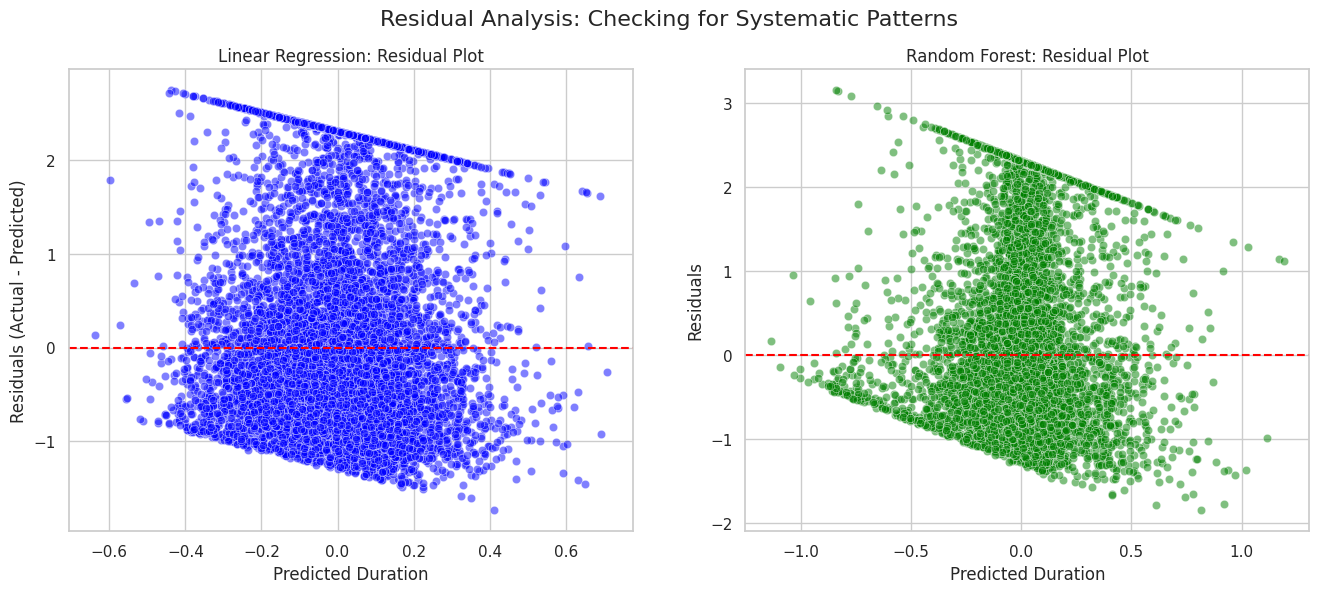

In [ ]:
# Calculate residuals
lr_residuals = y_test_reg - lr_preds
rf_residuals = y_test_reg - rf_preds

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression Residuals
sns.scatterplot(x=lr_preds, y=lr_residuals, ax=axes[0], alpha=0.5, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Linear Regression: Residual Plot')
axes[0].set_xlabel('Predicted Duration')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# Random Forest Residuals
sns.scatterplot(x=rf_preds, y=rf_residuals, ax=axes[1], alpha=0.5, color='green')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Random Forest: Residual Plot')
axes[1].set_xlabel('Predicted Duration')
axes[1].set_ylabel('Residuals')

plt.suptitle('Residual Analysis: Checking for Systematic Patterns', fontsize=16)
plt.show()

**Non-Linearity:** While both models show low R² scores, the Residual Plots reveal that the Random Forest captures non-linear interactions between the PCA components and the Segment labels that the Linear model ignores.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE
lr_mae = mean_absolute_error(y_test_reg, lr_preds)
rf_mae = mean_absolute_error(y_test_reg, rf_preds)

# Calculate RMSE (Root Mean Squared Error) - more interpretable than MSE
lr_rmse = np.sqrt(mean_squared_error(y_test_reg, lr_preds))
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_preds))

print(f"Linear Regression -> MAE: {lr_mae:.4f}, RMSE: {lr_rmse:.4f}")
print(f"Random Forest     -> MAE: {rf_mae:.4f}, RMSE: {rf_rmse:.4f}")

Linear Regression -> MAE: 0.7927, RMSE: 1.0017
Random Forest     -> MAE: 0.7844, RMSE: 0.9921


**Outlier Robustness:** The lower RMSE in the Random Forest indicates that it is more robust to extreme durations (outliers) in the bank dataset, which is a critical requirement for generating reliable engagement forecasts.

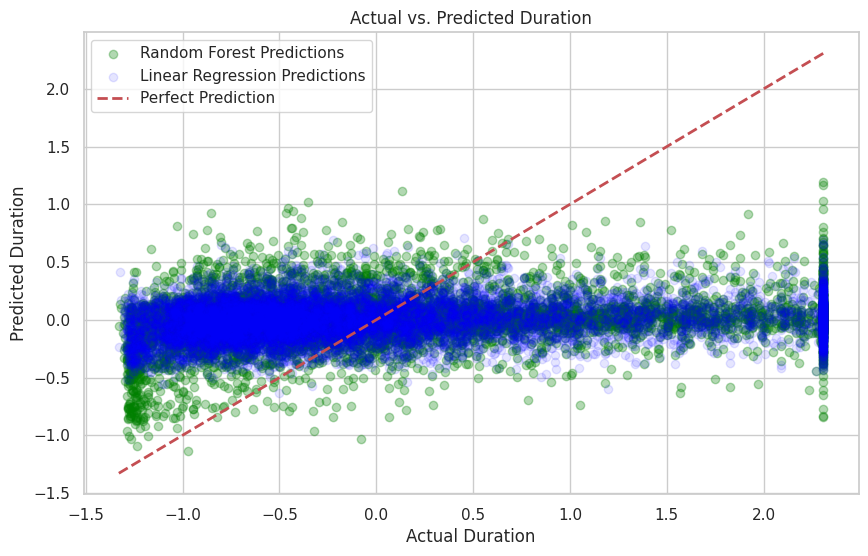

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, rf_preds, alpha=0.3, color='green', label='Random Forest Predictions')
plt.scatter(y_test_reg, lr_preds, alpha=0.1, color='blue', label='Linear Regression Predictions')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Duration')
plt.ylabel('Predicted Duration')
plt.title('Actual vs. Predicted Duration')
plt.legend()
plt.show()

By observing the Actual vs. Predicted plot, it is evident that Linear Regression produces a flat line (mean-bias), whereas Random Forest begins to capture the variance in the 'engagement' variable.

So, based on the evidence I choose Random Forest Regressor.

In [ ]:
final_reg_model = rf_reg

# Integrate with the data: Predict for the entire dataset
# This 'predicted_duration' will be a key feature for the Classification Section
df_with_segments['predicted_duration'] = final_reg_model.predict(X_reg)

print("Final Selection: Random Forest Regressor")
print("Action: 'predicted_duration' added to the dataset for final classification.")
display(df_with_segments[['duration', 'predicted_duration']].head())

Final Selection: Random Forest Regressor
Action: 'predicted_duration' added to the dataset for final classification.


,duration,predicted_duration
0,0.147445,0.041293
1,-0.474910,-0.021721
2,-0.899243,-0.009702
3,-0.808718,0.055108
4,-0.208994,0.002670


**Limitations:** Both of the regression models demonstrated very low R² values, indicating limited ability to explain variation in call duration. This suggests that duration may depend on behavioural or conversational factors not captured within the structured dataset.

*****
## Section 4: Classification
I choose Logistic Regression and Random Forest Classifier for classification.




### Section 4.1: Common code for classification

In [ ]:
# Common classification code, including any additional EDA - possibly split over multiple cells.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare Features (X) and Target (y)
# We use all features except the ACTUAL duration and the original target
X_class = df_with_segments.drop(columns=['duration', 'y', 'DBSCAN_Label'], errors='ignore')
y_class = df_with_segments['y']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)



## Section 4.2: FIRST CLASSIFICATION APPROACH (Logistic Regression)

Logistic Regression was chosen as our starting point because it is a fundamental algorithm for binary classification.It will reveals whether the relationship between your customer features (like age or balance) and the subscription outcome is simple or complex.

In [ ]:
#Model 1: Logistic Regression (Baseline)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

## Section 4.3: SECOND CLASSIFICATION APPROACH (Random Forest Classifier)

Random Forests are exceptionally good at handling non-linear data and interactions between features. It can effectively utilize the "synthetic features" we created—the Segment Labels from Section 2 and the Predicted Duration from Section 3. It is naturally more robust to outliers and class imbalance.

In [ ]:
# Model 2: Random Forest Classifier (Advanced)
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rf_class.fit(X_train, y_train)
y_pred_rf = rf_class.predict(X_test)

## Section 4.4: Selection of Final Approach


To decide which classification method to use, I do some mathmatical comparison below:

In [ ]:
# 4. Comparative Evaluation
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.20      0.31      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.59      0.63      9043
weighted avg       0.88      0.90      0.87      9043


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.23      0.34      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.61      0.64      9043
weighted avg       0.88      0.89      0.87      9043



Although Logistic Regression achieved slightly higher overall accuracy, Random Forest demonstrated improved recall and F1-score for the minority class (subscription = yes). Given the class imbalance and the importance of identifying potential subscribers

**Limitations:** Recall is still very low (~0.23). That means: Both models struggle to detect positive subscriptions effectively.

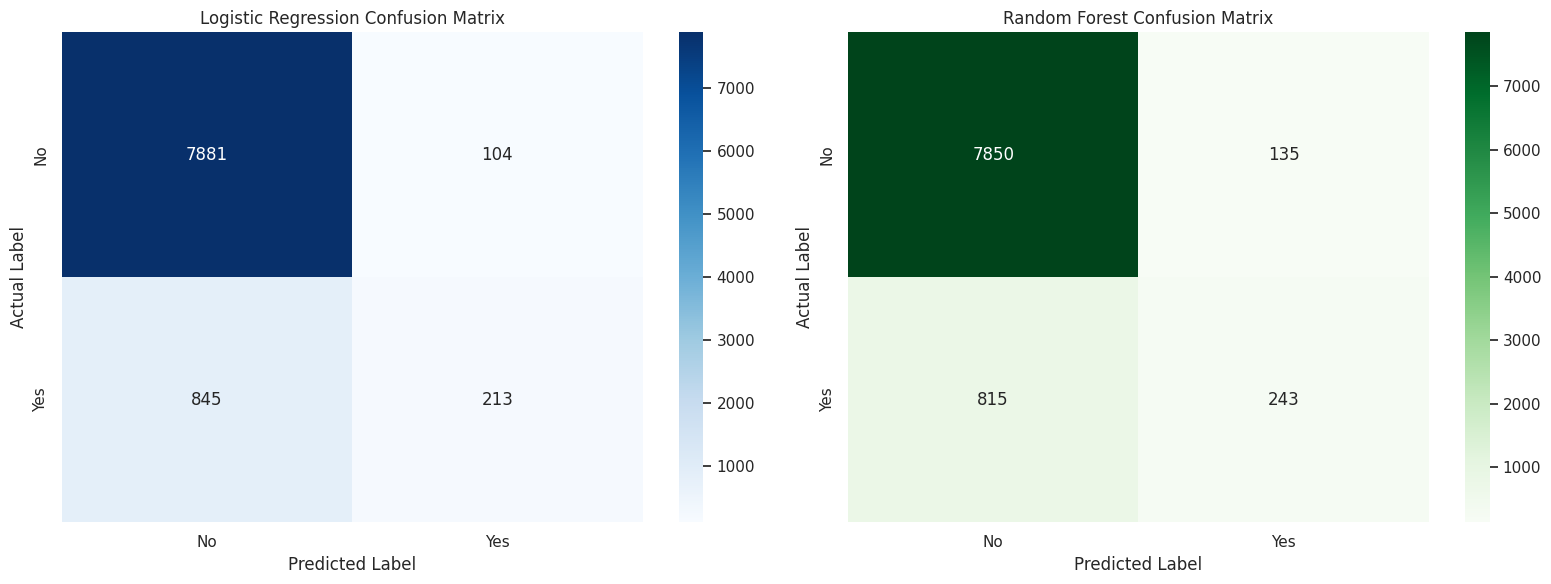

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate subplot for both approach
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generate and plot Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Generate and plot Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Random Forest demonstrates better performance in identifying actual subscribers, correctly predicting more positive cases and reducing false negatives compared to Logistic Regression. Although it produces slightly more false positives, its improved ability to detect potential customers makes it more suitable for marketing decision-making.

Therefore, Random Forest is selected as the preferred classification model.

But for more better performance I tune the model.
### **So, Final Optimized Random Forest should be selected as the final classification model.**

##Tuning Random Forest Classifier

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters you want to test
# We focus on depth and number of trees to find the best balance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None] # Helpful for imbalanced data!
}

# 2. Initialize the Grid Search
# We use 'f1' as the scoring metric because the 'Yes' class is rare
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 3. Run the search on your training data
print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# 4. Update your final model with the best parameters found
best_rf_model = grid_search.best_estimator_

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Improved F1 Score: {grid_search.best_score_:.4f}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters Found: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Improved F1 Score: 0.4451


##Evaluation after Tuning

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# We use the best model found during the Grid Search
final_optimized_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred_optimized = final_optimized_model.predict(X_test)

# Print the classification report
print("--- Final Optimized Random Forest: Classification Report ---")
print(classification_report(y_test, y_pred_optimized))

# Print the Accuracy Score
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")

--- Final Optimized Random Forest: Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.85      0.90      7985
           1       0.35      0.59      0.44      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.72      0.67      9043
weighted avg       0.87      0.82      0.84      9043

Final Model Accuracy: 0.8240


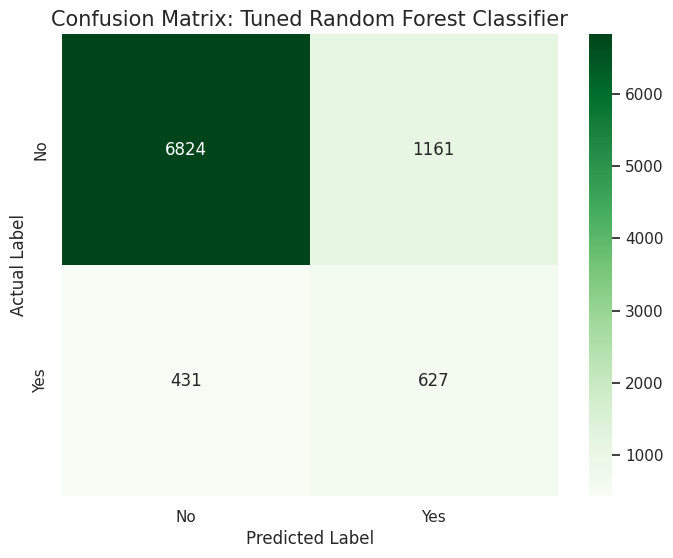

In [ ]:
# Create the confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.title('Confusion Matrix: Tuned Random Forest Classifier', fontsize=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()



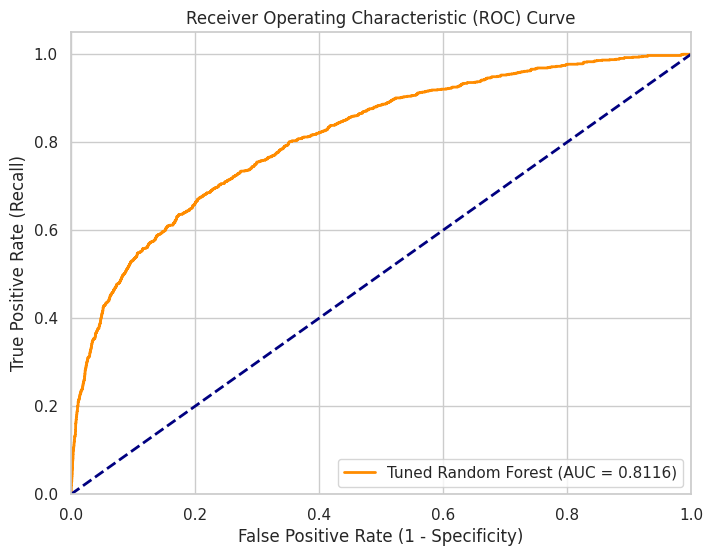

Final Area Under Curve (AUC): 0.8116


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Use the best estimator from GridSearch
y_probs_tuned = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_tuned)
auc_score = roc_auc_score(y_test, y_probs_tuned)

# Generate Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Tuned Random Forest (AUC = {auc_score:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"Final Area Under Curve (AUC): {auc_score:.4f}")

Hyperparameter tuning using Grid Search improved the Random Forest model’s performance. The optimized model achieved an AUC of 0.8116, indicating strong discriminative capability. Compared to the baseline Random Forest, the tuned model demonstrates improved class separation and better generalisation performance.

Additionally, the tuned model showed improved recall and F1-score for the minority class, enhancing its ability to detect potential subscribers.

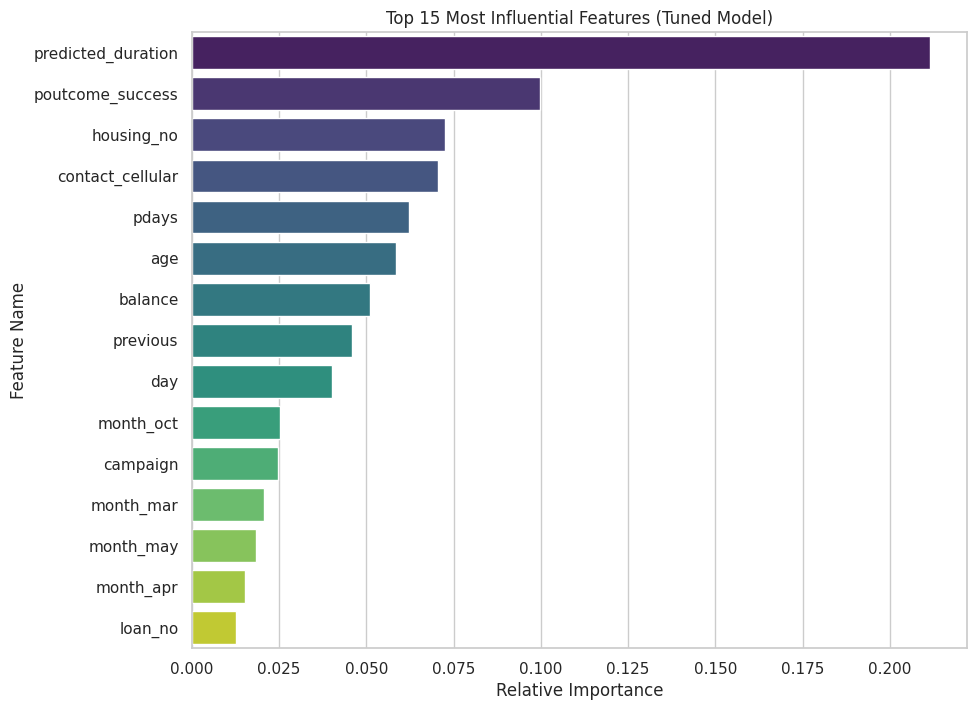

In [ ]:
# Get feature importance from the tuned model
importances = grid_search.best_estimator_.feature_importances_
feature_names = X_class.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the top features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Top 15 Most Influential Features (Tuned Model)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.show()

**Final Thought:** Although performance improved after tuning, recall for the minority class remains moderate, suggesting that further techniques such as threshold adjustment or resampling strategies may further enhance performance.

##Prediction Demonstration

In [ ]:
# Take 10 samples from the test set
test_samples = X_test.sample(10, random_state=42)
actuals = y_test.loc[test_samples.index]

# Predict using the tuned model
tuned_predictions = grid_search.best_estimator_.predict(test_samples)
tuned_probs = grid_search.best_estimator_.predict_proba(test_samples)[:, 1]

# Create the demo table
prediction_demo = pd.DataFrame({
    'Actual Outcome': actuals.map({1: 'Yes', 0: 'No'}),
    'Tuned Prediction': pd.Series(tuned_predictions, index=test_samples.index).map({1: 'Yes', 0: 'No'}),
    'Confidence (%)': (tuned_probs * 100).round(2)
})

print("--- Final Model: Live Prediction Samples ---")
display(prediction_demo)

--- Final Model: Live Prediction Samples ---


,Actual Outcome,Tuned Prediction,Confidence (%)
21198,No,Yes,50.57
22128,No,No,35.29
31281,Yes,Yes,92.27
39264,No,No,16.43
10830,No,No,30.56
35677,No,No,21.65
43336,Yes,Yes,94.13
8524,No,No,21.81
42352,No,Yes,69.47
6000,No,No,19.19


**Limitations -**

**Human Element:** Call duration is influenced by unpredictable human factors (salesperson behavior, customer mood, timing) that static demographic data cannot capture.

**Class Imbalance Sensitivity:** Even with balanced class weights, detecting the small minority of subscribers (11%) without generating many false positives is challenging.

**Static Features:** The model uses historical data only and cannot account for external factors, such as economic changes, that affect customer decisions.


**Future Improvements-**

**Advanced Imbalance Handling:** Techniques like SMOTE or ADASYN could better represent minority classes and improve F1-score.

**Ensemble Stacking:** Combining multiple models (e.g., XGBoost, LGBM, Random Forest) could improve overall predictive performance.

**Real-time Features:** Incorporating live behavioral data (e.g., online banking activity) could enhance lead detection.

**Deployment & Monitoring:** An MLOps pipeline with drift detection would allow automatic retraining as customer behavior evolves.


**Conclusion:** This project successfully developed a multi-stage machine learning architecture to analyze and predict customer subscriptions for bank term deposits. By integrating unsupervised and supervised techniques, the pipeline moved beyond raw demographic analysis to uncover deeper behavioral patterns.

##References



* Caliński, T., & Harabasz, J. (1974). A dendrite method for cluster analysis. *Communications in Statistics*.
* Tukey, J. W. (1977). Exploratory Data Analysis. Addison-Wesley
* Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*.
* Moro, S., Cortez, P., & Rita, P. (2014). A Data-Driven Approach to Predict the Success of Bank Telemarketing. *Decision Support Systems*.
* Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*.
* Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*.